# **Entrega 3 - Proyecto Integrador**

En este Notebook se desarrolla la tercera entrega del Proyecto Integrador de Ciencia de Datos, utilizando como entrada las hipótesis y los resultados del análisis exploratorio realizado en la entrega anterior.



---

## ***Introducción***
En esta entrega, con el uso de un modelo de *Machine Learning*, vamos a utilizar distintos modelos para:
1. Predecir el género de peliculas.
2. Intentar agrupar y/o clasificar las peliculas en base a sus características


#### *1. Aprendizaje supervisado: Clasificación de Género*
**Objetivo predictivo:** predecir el género primario (genre) de una pelicula basándose en sus propiedades y su contexto temporal.

Esto se hará a partir de sus características, tales como:

| Característica | Descripcion                                               |
| -------------- | --------------------------------------------------------- |
| `happy`        | Porcentaje de "felicidad" de una pelicula                  |
| `sad`          | Porcentaje de "tristeza" de una pelicula                   |  
| `romantic`    | Porcentaje de "romance" de una pelicula                   |  
| `intense`        | Porcentaje de "intensidad" de una pelicula                   |  
| `mysterious`        | Porcentaje de "misterio" de una pelicula                  |  
| `dark`       | Porcentaje de "oscuridad" de una pelicula             |  
| `adventurous`      | Porcentaje de "aventura" de una pelicula                   |
| `fantastical`     | Porcentaje de "fantasia" de una pelicula                   |
| `humorous` | Porcentaje de "humor" de una pelicula                |
| `friendly` | Porcentaje de "amigable" de una pleicula

Los géneros posibles de las canciones son:
1.   ***Drama***
2.   ***Horror-Thiller-Mystery***
3.   ***Comedy***
4.   ***Action-Adventure***
5.   ***Romantic-Comedy***
6.   ***Crime***
7.   ***Animation-Family***
8.   ***Sci-Fi***
9.   ***Musical***
10.   ***Otro***





#### *2. Aprendizaje no supervisado: Agrupación de canciones con características similares*
**Objetivo predictivo:** identificar grupos naturales de peliculas dentro del conjunto de datos, utilizando las características mencionadas anteriormente (`happy`, `sad`, `romantic`, `dark`, etc.), esperando poder dividir según los géneros, o conseguir alguna división que sea de interés.

---
## ***Objetivo general de la entrega***
El objetivo general de esta entrega es conseguir un punto de partida para construir un modelo de recomendación de canciones basado en las características de las mismas, y del evento o estado de ánimo específico del usuario.



---


## ***Preparación inicial***
En esta sección, vamos a preparar los datos a utilizar en el modelo a realizar.

Vamos a importar el archivo con el que vamos a trabajar, seleccionar la variable objetivo y las features. Además, vamos a separar en conjunto de entrenamiento y test.

### 1. Importación del archivo
Acá vamos a importar el archivo *songs_final_entrante*, que es la salida de la entrega anterior.

In [ ]:
import pandas as pd

!gdown 1HY-gGekPfGQOi0-BF9xmBiCRldIL9J6y
df = pd.read_csv("dataset_3000.csv")

df.head()

Downloading...
From: https://drive.google.com/uc?id=1HY-gGekPfGQOi0-BF9xmBiCRldIL9J6y
To: /content/dataset_3000.csv
100% 1.88M/1.88M [00:00<00:00, 89.7MB/s]


,imdb_title_id,title,original_title,year,date_published,genre,duration,country,language,director,...,romantic,intense,sad,happy,mysterious,dark,adventurous,fantastical,humorous,friendly
0,tt0243585,Stuart Little 2,Stuart Little 2,2002.0,2002-08-30,Action-Adventure,77,USA,English,Rob Minkoff,...,0.000000,0.180405,0.0,0.000000,0.0,0.0,0.099768,0.000000,0.060960,0.000000
1,tt0116583,Il gobbo di Notre Dame,The Hunchback of Notre Dame,1996.0,1996-12-06,Animation-Family,91,"USA, France","English, Latin","Gary Trousdale, Kirk Wise",...,0.000000,0.000000,0.0,0.065499,0.0,0.0,0.000000,0.000000,0.000000,0.065499
2,tt0186993,Epitaph - Follia omicida,Epitaph,1987.0,1987,Horror-Thriller-Mystery,94,USA,English,Joseph Merhi,...,0.000000,0.000000,0.0,0.072327,0.0,0.0,0.000000,0.000000,0.000000,0.169876
3,tt1979305,Pocong Mandi Goyang Pinggul,Pocong Mandi Goyang Pinggul,2011.0,2011-04-28,Horror-Thriller-Mystery,90,Indonesia,Indonesian,Yoyok Subagyo,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.176294,0.051187,0.000000
4,tt9135800,Brother's Day,Brother's Day,2019.0,2019-09-06,Romantic-Comedy,165,India,Malayalam,Kalabhavan Shajohn,...,0.038667,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.028712,0.062088


In [ ]:
df.shape

(3000, 30)

Además de lo anterior, comprobaremos qué columnas poseen valores nulos que podrían traernos problemas a futuro.

In [ ]:
cols_with_nulls = df.columns[df.isna().any()]

print(f"Columnas con valores nulos: {cols_with_nulls}")

Columnas con valores nulos: Index([], dtype='object')


Antes de comenzar, queremos comprobar la proporción de cada género que poseen nuestros datos.

In [ ]:
frecuencias = df['genre'].value_counts()

frecuencias_df = frecuencias.reset_index()
frecuencias_df.columns = ['genre', 'cantidad']

frecuencias_df

,genre,cantidad
0,Drama,781
1,Horror-Thriller-Mystery,709
2,Comedy,457
3,Action-Adventure,357
4,Romantic-Comedy,242
5,Crime,239
6,Animation-Family,93
7,Sci-Fi,71
8,Musical,43
9,Otro,8


In [ ]:
df_temp = df.copy()

df_temp["genre"] = df_temp["genre"].str.split(",")

df_temp = df_temp.explode("genre")

df_temp["genre"] = df_temp["genre"].str.strip()

frecuencias = df_temp['genre'].value_counts(normalize=True) * 100
frecuencias_df = frecuencias.reset_index()
frecuencias_df.columns = ['genre', 'porcentaje']

frecuencias_df

,genre,porcentaje
0,Drama,26.033333
1,Horror-Thriller-Mystery,23.633333
2,Comedy,15.233333
3,Action-Adventure,11.900000
4,Romantic-Comedy,8.066667
5,Crime,7.966667
6,Animation-Family,3.100000
7,Sci-Fi,2.366667
8,Musical,1.433333
9,Otro,0.266667


Si hay géneros con menos del 1% de las peliculas. Por lo tanto, procedemos a eliminarlo ya que lo consideramos poco representativo y así no tendremos problemas al predecir.

In [ ]:
poco_frecuentes = frecuencias[frecuencias < 0.3].index
df = df[~df['genre'].isin(poco_frecuentes)]

In [ ]:
# Mostrar cuántos duplicados hay antes
duplicados = df.duplicated(subset=['imdb_title_id'])
print(f"Cantidad de canciones duplicadas: {duplicados.sum()}")

# Eliminar duplicados conservando la primera aparición
df_sin_duplicados = df.drop_duplicates(subset=['imdb_title_id'], keep='first')
df=df_sin_duplicados
# Verificar resultado
print(f"Cantidad de filas antes: {len(df)}")
print(f"Cantidad de filas después de eliminar duplicados: {len(df_sin_duplicados)}")

Cantidad de canciones duplicadas: 0
Cantidad de filas antes: 2992
Cantidad de filas después de eliminar duplicados: 2992


In [ ]:
df_a_eliminar = df

df_a_eliminar = df_a_eliminar[~df_a_eliminar['director'].isna()]

df = df_a_eliminar

In [ ]:
df.shape

(2992, 30)

### 2. Selección de features y variable objetivo
En esta subsección, vamos a seleccionar la variable objetivo (`genre`) y las features con las que vamos a predecir el objetivo.

Por el momento, vamos a seleccionar como features a todas las demás columnas que no sean `genre`.


In [ ]:
# Variable objetivo
y = df["genre"]

# Features (por ahora, solamente sacamos la objetivo)
X = df.drop(columns=["genre"])

### 3. División en conjunto de entrenamiento y test
Aquí, vamos a separar el .csv de los datos en dos conjuntos: entrenamiento (80%) y test (20%). Además, vamos a verificar el tamaño de cada uno.
- Conjunto de entrenamiento: utilizado para entrenar el pipeline.
- Conjunto de prueba: utilizado para la evaluación final.

Como estrategia, utilizaremos `stratify=y` al momento de la división para asegurar que la proporción de los 14 géneros sea la misma tanto en el conjunto de entrenamiento como en el de pruebas, así evitaremos posibles sesgos.

In [ ]:
# Hacemos una copia
df_temp = df.copy()

# Separamos los géneros
df_temp["genre"] = df_temp["genre"].str.split(",")

# Explotamos para que cada género sea individual
df_temp = df_temp.explode("genre")

# Limpiamos espacios
df_temp["genre"] = df_temp["genre"].str.strip()

# Definimos X e y a partir del nuevo dataset
X = df_temp.drop(columns=["genre"])
y = df_temp["genre"]

# Filtramos clases con al menos 2 ejemplos (necesario para stratify)
conteo = y.value_counts()
clases_validas = conteo[conteo >= 2].index

mask = y.isin(clases_validas)
X = X[mask]
y = y[mask]

In [ ]:
from sklearn.model_selection import train_test_split

# Separamos los conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Verificamos tamaño de cada conjunto
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de test: {X_test.shape[0]} muestras")

Conjunto de entrenamiento: 2393 muestras
Conjunto de test: 599 muestras




---


## ***Preprocesamiento de los datos***
En esta sección, vamos a construir un pipeline que va a servir para dejar listos los datos para la predicción.

### 1. Limpieza de columnas irrelevantes
Acá vamos a eliminar aquellas columnas que no son relevantes para la predicción, que son:
* `title`
* `imdb_title_id`
* `director`
* `year`
* `duration`
* `longitud_titulo`


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop=None):
        self.columns_to_drop = columns_to_drop or []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.columns_to_drop)

### 2. Pipeline numérico
A pesar de haber observado que nuestras variables numéricas todas poseen valores, es decir, no hay filas con valores nulos. Para prevenir cualquier inconveniente, en nuestro pipeline numérico agregaremos la imputación. Además, a pesar de saber que nuestras variables numéricas poseen valores que se encuentran entre 0 y 1, por las dudas realizaremos el escalado.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

### 2. Pipeline categórico
Una de las variables que no fue eliminada fue la década. Utilizaremos a esta variable como categórica ya que quizás pueda traernos información útil para predicciones.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

### 3. Composición con el ColumnTransformer

In [ ]:
from sklearn.compose import ColumnTransformer, make_column_selector

column_transform = ColumnTransformer([
    ("num", numeric_pipeline, make_column_selector(dtype_include=["int64", "float64"])),
    ("cat", categorical_pipeline, make_column_selector(dtype_include=["object", "category"]))
])

### 4. Ingenieria de caracteristicas


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import numpy as np

class MovieIndexCreator(BaseEstimator, TransformerMixin):
    def __init__(self, drop_original=True):
        self.drop_original = drop_original

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
             column_names = ['sad', 'happy', 'romantic', 'dark', 'fantastical', 'humorous',
                             'adventurous', 'intense', 'mysterious', 'friendly']
             X_ = pd.DataFrame(X, columns=column_names)
        else:
             X_ = X.copy()

        # Índice de Ánimo
        X_["mood_index"] = X_["happy"] - X_["sad"]

        # Índice de Energía
        X_["energy_index"] = X_["intense"] - X_["humorous"]


        # Eliminación de las columnas originales
        if self.drop_original:
            X_ = X_.drop(columns=["sad", "happy", "intense", "humorous"])

        return X_

### 4. Pipeline final
Por último, vamos a correr el pipeline con la función creada anteriormente.

In [ ]:
from sklearn.pipeline import Pipeline

preprocessor = Pipeline([
    ("drop_columns", DropColumns(columns_to_drop=["year", "title","imdb_title_id","director", "longitud_titulo", "duration"])),
    ("movie_index_creator", MovieIndexCreator()),
     ("column_transform", column_transform)
])

In [ ]:
# Mostramos la salida del preprocesamiento
preprocessor.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 38415 stored elements and shape (2393, 14014)>



---


## ***Entrenamiento de modelos: Aprendizaje supervisado***
En esta sección, vamos a entrenar a los modelos sin ningún ajuste.

Pero antes, vamos a declarar la función a utilizar para evaluar los modelos. Esta función se va a llamar cada vez que se realice una predicción.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluar_modelo_prediccion(nombre, y_true, y_pred):
    print(f"\n MODELO: {nombre}\n")
    print("Reporte de clasificación:")
    print(classification_report(y_true, y_pred, digits=3))
    print("Matriz de confusión:")
    print(confusion_matrix(y_true, y_pred))

### ***1. K-Neighbors Classifier (KNN)***

***Funcionamiento del modelo***:
Al intentar predecir el género de una pelicula, busca las peliculas más cercanas en el conjunto de entrenamiento, pero "cercanas" en términos de similitud numérica entre sus características. Es decir, al recibir una nueva pelicula para predecirle el género, el modelo:
1. Calcula la distancia entre esa pelicula y cada una de las peliculas del conjunto de entrenamiento.
2. Ordena esas distancias de menor a mayor.
3. Se queda con las K peliculas (filas) que resultan más cercanas numéricamente.
4. Mira las etiquetas de género de esas peliculas y asigna la clase mayoritaria entre ellas.



Decidimos iniciar con el modelo KNN ya que es sencillo y transparente y creemos que puede ser una buena base.

Este modelo, clasifica una pelicula nueva asignándole el género de sus K vecinos más cercanos en el espacio de características.

Nosotras partimos con un K=5 como valor inicial, ya que es un valor común que balancea el ruido (K=1) y la suavización excesiva (K alto).



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

pipeline_k_neighbors = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

pipeline_k_neighbors.fit(X_train, y_train)

y_pred_k_neighbors = pipeline_k_neighbors.predict(X_test)

evaluar_modelo_prediccion("K-Neighbors Classifier", y_test, y_pred_k_neighbors)


 MODELO: K-Neighbors Classifier

Reporte de clasificación:
                         precision    recall  f1-score   support

       Action-Adventure      0.263     0.282     0.272        71
       Animation-Family      0.267     0.211     0.235        19
                 Comedy      0.328     0.435     0.374        92
                  Crime      0.297     0.229     0.259        48
                  Drama      0.421     0.494     0.454       156
Horror-Thriller-Mystery      0.507     0.486     0.496       142
                Musical      0.000     0.000     0.000         9
        Romantic-Comedy      0.192     0.104     0.135        48
                 Sci-Fi      0.000     0.000     0.000        14

               accuracy                          0.377       599
              macro avg      0.253     0.249     0.247       599
           weighted avg      0.359     0.377     0.365       599

Matriz de confusión:
[[20  6  7  3 21 12  0  1  1]
 [ 2  4  6  0  3  1  0  3  0]
 [ 7  2 40 

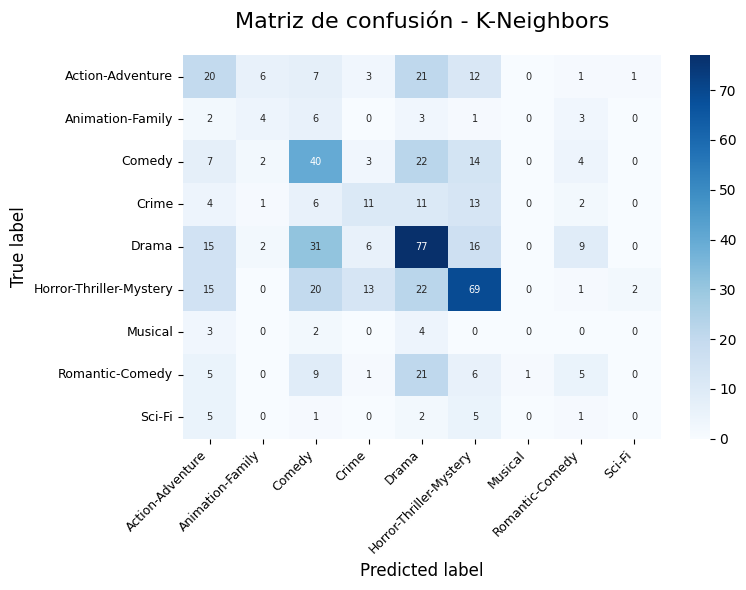

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Obtener la matriz de confusión como array
cm = confusion_matrix(y_test, pipeline_k_neighbors.predict(X_test))

# Crear figura grande
fig, ax = plt.subplots(figsize=(8, 6))  # Tamaño grande

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=pipeline_k_neighbors.classes_,
    yticklabels=pipeline_k_neighbors.classes_,
    ax=ax,
    annot_kws={"size": 7}  # Fuente pequeña para los números
)

ax.set_title('Matriz de confusión - K-Neighbors', fontsize=16, pad=20)
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)

# Rotar etiquetas del eje X para que no se superpongan
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

#### Análisis de resultados
Teniendo un k=5, el rendimiento inicial fue moderado, obteniendo un `accuracy` aproximado del 38%.

Además, notamos un desempeño bastante desigual entre las clases.

Esto nos indicó que le modelo, inicialmente no está muy bien configurado ya que no está detectando bien las diferencias tonales entre géneros.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_kn = {'classifier__n_neighbors': np.arange(1, 21)}

grid_search_kn = GridSearchCV(
    pipeline_k_neighbors,
    param_grid_kn,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search_kn.fit(X_train, y_train)

print(f"Mejor valor de K encontrado: {grid_search_kn.best_params_['classifier__n_neighbors']}")
print(f"Mejor precisión con Cross-Validation: {grid_search_kn.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejor valor de K encontrado: 15
Mejor precisión con Cross-Validation: 0.3778


Se identificó que con un `K=15` como el valor óptimo. Luego, aplicamos la modificación en nuestro modelo, para ver si realmente mejora con este ajuste.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

pipeline_k_neighbors_v2 = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=15))
])

pipeline_k_neighbors_v2.fit(X_train, y_train)

y_pred_k_neighbors_v2 = pipeline_k_neighbors_v2.predict(X_test)

evaluar_modelo_prediccion("K-Neighbors Classifier v2", y_test, y_pred_k_neighbors_v2)


 MODELO: K-Neighbors Classifier v2

Reporte de clasificación:
                         precision    recall  f1-score   support

       Action-Adventure      0.259     0.099     0.143        71
       Animation-Family      0.000     0.000     0.000        19
                 Comedy      0.320     0.424     0.364        92
                  Crime      0.565     0.271     0.366        48
                  Drama      0.371     0.571     0.449       156
Horror-Thriller-Mystery      0.439     0.507     0.471       142
                Musical      0.000     0.000     0.000         9
        Romantic-Comedy      0.238     0.104     0.145        48
                 Sci-Fi      0.000     0.000     0.000        14

               accuracy                          0.376       599
              macro avg      0.244     0.219     0.215       599
           weighted avg      0.345     0.376     0.342       599

Matriz de confusión:
[[ 7  1 10  1 30 18  0  4  0]
 [ 1  0  4  0  6  6  0  2  0]
 [ 1  1 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


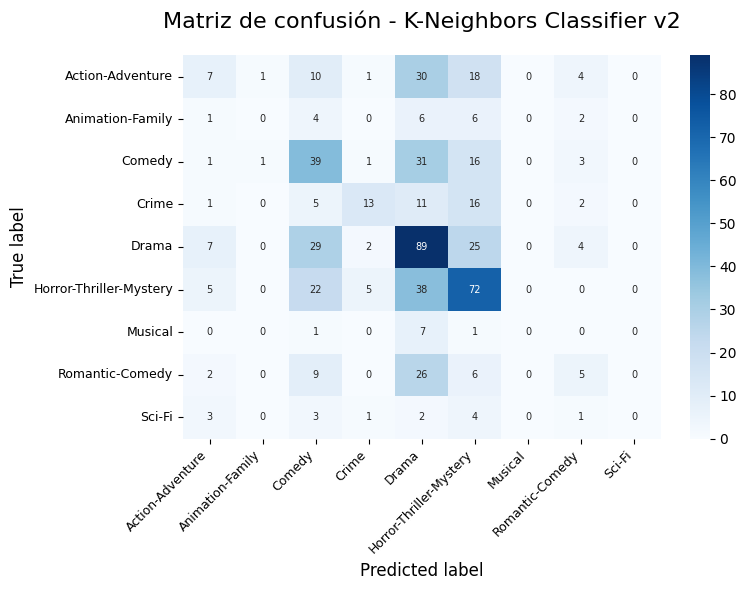

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pipeline_k_neighbors_v2.predict(X_test))
clases = pipeline_k_neighbors_v2.classes_

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=clases,
    yticklabels=clases,
    ax=ax,
    annot_kws={"size": 7}
)

ax.set_title('Matriz de confusión - K-Neighbors Classifier v2', fontsize=16, pad=20)
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

Observamos que no se obtuvo una leve mejora luego del ajuste del hiperparámetro k (pasando de K=5 a K=15),
alcanzando un accuracy del 38%.

Sin embargo, esta mejora no resulta significativa, ya que el rendimiento del modelo continúa siendo bajo
en términos generales. Cabe destacar que el modelo no empeoró con el ajuste, lo cual confirma que K=15
es efectivamente el valor óptimo dentro del rango evaluado.

Esto implica que, si bien el modelo mejora levemente al ajustar sus parámetros, su capacidad predictiva
sigue siendo limitada, por lo que no resulta el más adecuado para este problema en particular.

In [ ]:
from sklearn.metrics import accuracy_score

y_pred_train_knn2 = pipeline_k_neighbors_v2.predict(X_train)
y_pred_test_knn2 = pipeline_k_neighbors_v2.predict(X_test)

acc_train_knn2 = accuracy_score(y_train, y_pred_train_knn2)
acc_test_knn2 = accuracy_score(y_test, y_pred_test_knn2)

print("Accuracy Train:", acc_train_knn2)
print("Accuracy Test:", acc_test_knn2)


Accuracy Train: 0.467195988299206
Accuracy Test: 0.3756260434056761


Como se observa en la comparación anterior, para el conjunto de train se obtiene una precisión mayor (alrededor de 46%), mientras que en el conjunto de test el rendimiento disminuye (aproximadamente 38%).

Esto indica que el modelo logra ajustarse mejor a los datos de entrenamiento, pero pierde capacidad de generalización al evaluar datos no vistos. Sin embargo, la diferencia entre ambos valores no es extremadamente alta, por lo que no se trata de un sobreajuste severo, sino más bien de un rendimiento general limitado del modelo.

En este caso, podríamos concluir que el modelo no está logrando capturar correctamente los patrones del problema, posiblemente debido a la complejidad de los datos, la cantidad de clases y el desbalance entre ellas.

#### **Validacion cruzada** (teniendo K=1)
Se utilizó la técnica de validación cruzada para evaluar el rendimiento real del modelo. Es por ello que se dividió el conjunto de entrenamiento en 5 subconjuntos (folds) de manera que:
- se entrena con 4 folds y se evalúa con el fold restante
- se repite este proceso 5 veces cambiando el fold de validación
- se calcula el promedio de rendimiento

Esto nos permite estimar cómo generaliza el modelo en diferentes particiones de los datos.

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

# pipeline con tu preprocesador
pipeline_knn_v3 = Pipeline([
    ("preprocessing", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=1))
])

# validación cruzada estratificada con 5 particiones
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pipeline_knn_v3, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
print("Scores en cada fold:", scores)
print("Accuracy promedio:", scores.mean())


Scores en cada fold: [0.3256785  0.3131524  0.3256785  0.31171548 0.33263598]
Accuracy promedio: 0.3217721718014343


Utilizando un `k=1`, se observa que el modelo acierta aproximadamente el 32% de las veces al predecir el género de la pelicula durante la validación cruzada.

### ***2. Random Forest Classifier***

***Funcionamiento del modelo***:
este modelo, en lugar de entrenar un sólo árbol, entrena muchos árboles distintos y luego combina sus resultados para obtener una predicción más precisa y estable. Básicamente, el modelo:
1. Crea muchos árboles de decisión.
2. Cada árbol se entrena con una muestra aleatoria de las filas del data set y una selección aleatoria de variables en cada decisión (los árboles aprenden cosas ligeramente diferentes).
3. Cuando se hace una predicción, cada árbol "vota" por una clase y el bosque elige la clase con mayoría de votos.


Dado que observamos una baja precisión en el KNN en la predicción de géneros complejos, decidimos probar con Random Forest.

Este algoritmo, es un ensamble de árboles de decisión. Es por ello que maneja muy bien las interacciones complejas y funciona mejor con respecto a la mezcla de características numéricas y características categóricas.



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Pipeline con Random Forest
pipeline_rf = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

# Entrenar
pipeline_rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = pipeline_rf.predict(X_test)

evaluar_modelo_prediccion("Random Forest Classifier", y_test, y_pred_rf)


 MODELO: Random Forest Classifier

Reporte de clasificación:
                         precision    recall  f1-score   support

       Action-Adventure      0.702     0.465     0.559        71
       Animation-Family      0.000     0.000     0.000        19
                 Comedy      0.638     0.804     0.712        92
                  Crime      0.773     0.354     0.486        48
                  Drama      0.662     0.827     0.735       156
Horror-Thriller-Mystery      0.549     0.711     0.620       142
                Musical      0.000     0.000     0.000         9
        Romantic-Comedy      0.771     0.562     0.651        48
                 Sci-Fi      0.000     0.000     0.000        14

               accuracy                          0.636       599
              macro avg      0.455     0.414     0.418       599
           weighted avg      0.607     0.636     0.605       599

Matriz de confusión:
[[ 33   0   8   0  15  13   0   2   0]
 [  0   0   8   0   7   4   0 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


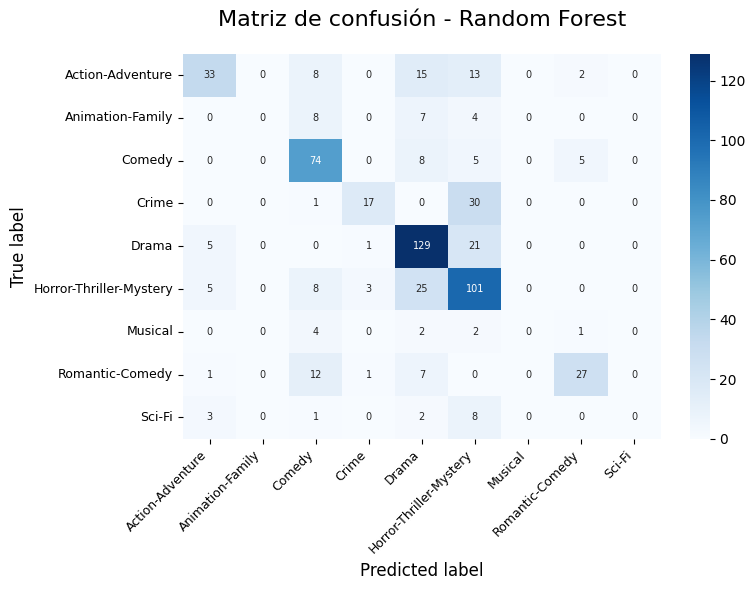

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pipeline_rf.predict(X_test))
clases = pipeline_rf.classes_

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=clases,
    yticklabels=clases,
    ax=ax,
    annot_kws={"size": 7}
)

ax.set_title('Matriz de confusión - Random Forest', fontsize=16, pad=20)
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

Como podemos ver en los resultados obtenidos, se mejoró mucho con respecto al modelo anterior, tenemos un 64% aproximadamente. Sin embargo, consideramos que quizás podría mejorar aún más, por ello también probaremos realizar el ajuste de hiperparámetros.

#### Ajuste de hiperparámetros
Utilizamos GridSearchCV para la búsqueda de hiperparámetros para ver cómo mejorar nuestro modelo.



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {'model__n_estimators': [100, 300, 500],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5]}

grid_search_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

best_rf_model = grid_search_rf.best_estimator_

print(f"Mejores parámetros: {grid_search_rf.best_params_}")
print(f"Mejor precisión con Cross-Validation: {grid_search_rf.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Mejores parámetros: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Mejor precisión con Cross-Validation: 0.6180


Según lo que vemos en los resultados anteriores, será conveniente aplicar los siguientes ajustes a nuestro modelo:

- `max_depth`: None (límite de profundidad)
- `min_samples_split`: 2 (mínimo de muestras para poder dividir)
- `n_estimators`: 300 (cantidad de árboles)

Entonces, procedemos a realizar dichas modificaciones.

Sin embargo, al establecer un límite de profundidad en 20, se busca evitar que los árboles crezcan de manera excesiva, reduciendo así el riesgo de sobreajuste. Además, al aumentar el valor de min_samples_split, se restringe la creación de divisiones poco representativas, lo que contribuye a mejorar la generalización del modelo.

En base a estos resultados, se observa que el modelo logra una precisión cercana al 62% en validación cruzada, lo cual representa una mejora respecto a modelos anteriores, aunque aún deja margen para seguir optimizando su rendimiento.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Pipeline con Random Forest
pipeline_rf_v2 = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        max_depth=None,
        n_estimators=300,
        min_samples_split=2,
        n_jobs=-1))
])

# Entrenar
pipeline_rf_v2.fit(X_train, y_train)

# Predicciones
y_pred_rf_v2 = pipeline_rf_v2.predict(X_test)

evaluar_modelo_prediccion("Random Forest Classifier", y_test, y_pred_rf_v2)


 MODELO: Random Forest Classifier

Reporte de clasificación:
                         precision    recall  f1-score   support

       Action-Adventure      0.738     0.437     0.549        71
       Animation-Family      0.000     0.000     0.000        19
                 Comedy      0.624     0.793     0.699        92
                  Crime      0.722     0.271     0.394        48
                  Drama      0.667     0.821     0.736       156
Horror-Thriller-Mystery      0.546     0.746     0.631       142
                Musical      0.000     0.000     0.000         9
        Romantic-Comedy      0.722     0.542     0.619        48
                 Sci-Fi      0.000     0.000     0.000        14

               accuracy                          0.629       599
              macro avg      0.447     0.401     0.403       599
           weighted avg      0.602     0.629     0.595       599

Matriz de confusión:
[[ 31   0   8   0  16  14   0   2   0]
 [  0   0   7   0   7   4   0 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


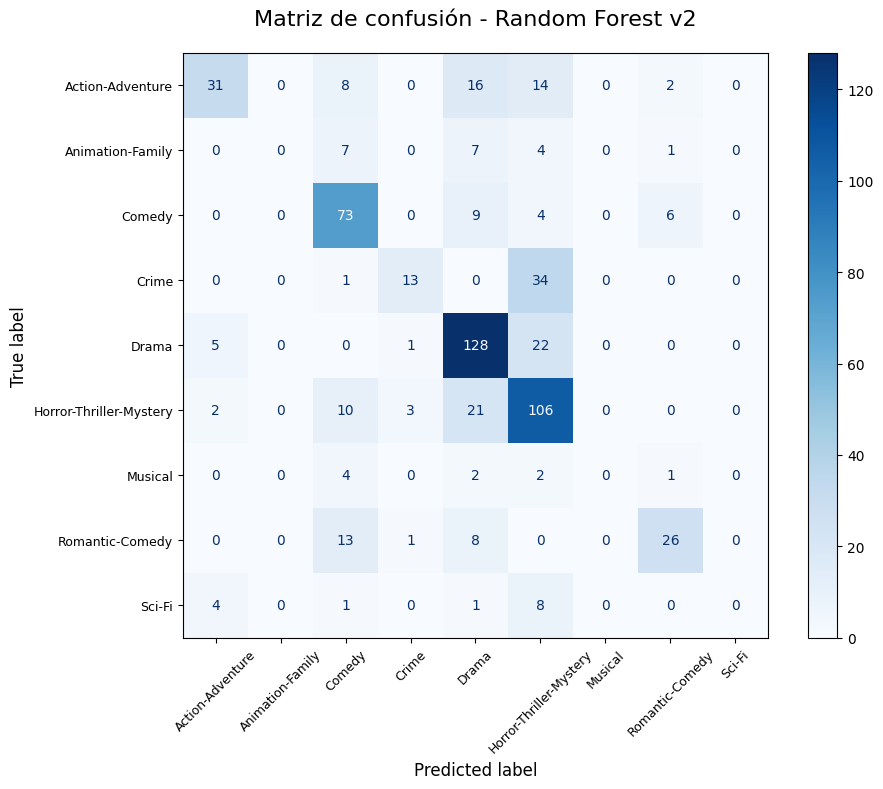

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay.from_estimator(
    pipeline_rf_v2,
    X_test,
    y_test,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

# Ajustes de estilo
ax.set_title("Matriz de confusión - Random Forest v2", fontsize=16, pad=20)
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)

# Tamaño de los ticks
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

Notamos que luego de ajustar los parametros, hubo muy pocas diferencias con el modelo básico anterior, es decir, los resultados son prácticamente iguales. Por lo que el modelo ajustado no mejora el rendimiento, solo mantiene el mismo nivel de desempeño. Es por ello que, a pesar del riesgo de sobreajuste, creemos que el bosque es lo suficientemente grande y estable como para que el ajuste no afecte su rendimiento.

Según lo investigado, en nuestro caso convendría utilizar el modelo con los hiperparámetros ajustados ya que no se empeora el rendimiento y al tener más árboles, es un poco más estable frente a variaciones. Además que la complejidad extra no pareciera afectar la generalización.

Ahora, para confirmar la estabilidad del modelo, aplicaremos validación cruzada en el modelo ajustado.


#### ***Validación cruzada***
Previo a la aplicación de validación cruzada, veremos el accuracy que se obtiene en el conjunto de entrenamiento y el del conjunto de test.

In [ ]:
y_pred_train_rf2 = pipeline_rf.predict(X_train)
y_pred_test_rf2 = pipeline_rf.predict(X_test)

acc_train_rf2 = accuracy_score(y_train, y_pred_train_rf2)
acc_test_rf2 = accuracy_score(y_test, y_pred_test_rf2)

print("Accuracy Train:", acc_train_rf2)
print("Accuracy Test:", acc_test_rf2)

Accuracy Train: 1.0
Accuracy Test: 0.6360601001669449


Dado que el valor de accuracy es mayor en el conjunto de entrenamiento (aproximadamente 100%) que en el de test (alrededor de 64%), podemos observar una diferencia moderada entre ambos.

Esto sugiere la presencia de un leve sobreajuste, ya que el modelo aprende mejor los datos de entrenamiento que aquellos no vistos. Sin embargo, la diferencia no es excesivamente grande, por lo que el modelo mantiene cierta capacidad de generalización.

A pesar de la mejora en comparación con modelos anteriores, el rendimiento aún no es óptimo, por lo que a continuación aplicaremos validación cruzada para obtener una evaluación más robusta del modelo.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline_rf_v2, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

print("Scores (RF2) en cada fold:", scores)
print("Accuracy (RF2) promedio:", scores.mean())

Scores (RF2) en cada fold: [0.6388309  0.58455115 0.60960334 0.63389121 0.61506276]
Accuracy (RF2) promedio: 0.6163878722233384


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline_rf, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

print("Scores (RF base) en cada fold:", scores)
print("Accuracy (RF base) promedio:", scores.mean())

Scores (RF base) en cada fold: [0.65135699 0.58455115 0.58872651 0.62761506 0.60251046]
Accuracy (RF base) promedio: 0.6109520357089823


Al ver estos resultados, podemos concluir que conviene utilizar el modelo Random Forest ajustado con hiperparámetros, ya que en la validación cruzada se obtuvo un mejor valor de accuracy (alrededor del 62%) para dicho modelo, mientras que para el modelo base se obtuvo un valor cercano al 61%.

Además, dados los resultados obtenidos, el modelo Random Forest ajustado presenta una mayor capacidad de generalización en comparación con el modelo base, ya que mantiene un mejor desempeño promedio en los distintos folds.

También se observa que, si bien ninguno de los modelos alcanza valores de accuracy elevados, el ajuste de hiperparámetros permite mejorar el rendimiento del modelo de manera consistente, por lo que resulta ser la mejor opción dentro de las evaluadas.

### ***3. Gradient Boosting (XGBoost)***
***Funcionamiento del modelo***: es un algoritmo de ensamble que combina muchas decisiones simples (árboles de decisión débiles). Se basa en aprender de los errores de manera iterativa.
Este modelo, funciona de la siguiente manera:
1. Entrena una serie de árboles de decisión de manera secuencial (no en paralelo como el Random Forest).
2. Cada nuevo árbol que se añade al ensamble se entrena para corregir los errores (residuos) cometidos por el conjunto de árboles anteriores.
3. Utiliza un método de optimización llamado descenso por el gradiente para identificar la dirección en la que debe  ir el siguiente árbol para minimizar la pérdida o el error general.
4. Se introduce un hiperparámetro llamado "tasa de aprendizaje" que controla cuánto debe confiar el modelo en el nuevo árbol.


Luego de investigar, encontramos el "Gradient Boosting" como posible modelo que mejore su rendimiento con respecto al Random Forest. Esto se debe a que XGBoost es conocido por ser "campeon" en la predicción de datos tabulares.

Es por ello que decidimos utilizar ahora este otro modelo .


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)

evaluar_modelo_prediccion("Gradient Boosting (XGBoost)", y_test, y_pred_xgb)


 MODELO: Gradient Boosting (XGBoost)

Reporte de clasificación:
                         precision    recall  f1-score   support

       Action-Adventure      0.755     0.563     0.645        71
       Animation-Family      0.250     0.053     0.087        19
                 Comedy      0.673     0.783     0.724        92
                  Crime      0.603     0.729     0.660        48
                  Drama      0.689     0.840     0.757       156
Horror-Thriller-Mystery      0.577     0.577     0.577       142
                Musical      0.000     0.000     0.000         9
        Romantic-Comedy      0.822     0.771     0.796        48
                 Sci-Fi      0.000     0.000     0.000        14

               accuracy                          0.664       599
              macro avg      0.486     0.480     0.472       599
           weighted avg      0.631     0.664     0.641       599

Matriz de confusión:
[[ 40   0   6   1  13   9   0   2   0]
 [  1   1   7   0   5   4  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


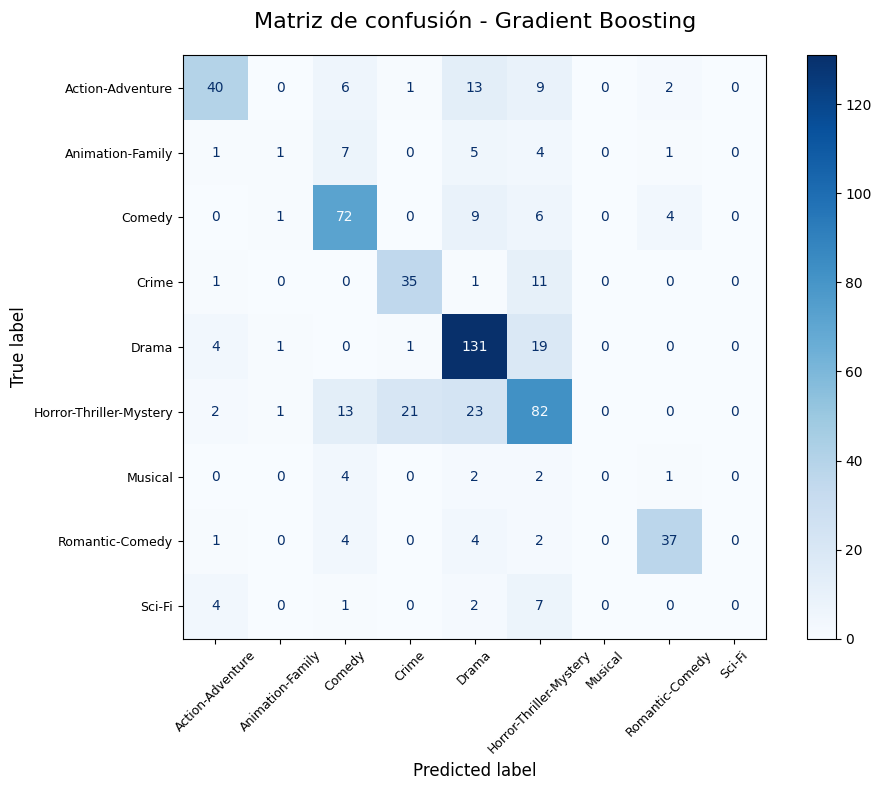

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay.from_estimator(
    xgb_pipeline,
    X_test,
    y_test,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

# Títulos y labels prolijos
ax.set_title("Matriz de confusión - Gradient Boosting", fontsize=16, pad=20)
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)

# Ajuste de tamaño de texto
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

De los resultados obtenidos, podemos concluir que obtuvo un accuracy mayor que con Random Forest, además se podría decir que el modelo es confiable al predecir el género mostrando un buen balance entre precisión y recall. Sin embargo, al ver el "Macro Avg F1", notamos que al ser inferior que el accuracy, el modelo tiene problemas con las clases minoritarias...

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb_pipeline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

print("Scores (XB base) en cada fold:", scores)
print("Accuracy (XB base) promedio:", scores.mean())

Scores (XB base) en cada fold: [0.6743215  0.65344468 0.65762004 0.65062762 0.65271967]
Accuracy (XB base) promedio: 0.6577467003258184


Observamos que al aplicar validación cruzada, se obtiene una precisión mayor que con random forest.

#### Ajuste de hiperparámetros
Utilizamos GridSearchCV para la búsqueda de hiperparámetros para ver cómo mejorar nuestro modelo.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
import numpy as np

param_grid_gb = {
    'classifier__n_estimators': [200, 400],
    'classifier__learning_rate': [0.1, 0.05],
    'classifier__max_depth': [3, 4]
}

gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

grid_search_gb = GridSearchCV(
    gb_pipeline,
    param_grid_gb,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

grid_search_gb.fit(X_train, y_train)

print(f"Mejor combinación de parámetros: {grid_search_gb.best_params_}")
print(f"Mejor Accuracy con validación cruzada: {grid_search_gb.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejor combinación de parámetros: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 200}
Mejor Accuracy con validación cruzada: 0.6636


Ahora, ejecutaremos el mismo modelo con el ajuste de hiperparámetros:
- `learning_rate` = 0.05
- `max_depth` = 4
- `n_estimators` = 200

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

xgb_pipeline_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

xgb_pipeline_v2.fit(X_train, y_train)

y_pred_xgb_v2 = xgb_pipeline_v2.predict(X_test)

evaluar_modelo_prediccion("Gradient Boosting (XGBoost)", y_test, y_pred_xgb_v2)


 MODELO: Gradient Boosting (XGBoost)

Reporte de clasificación:
                         precision    recall  f1-score   support

       Action-Adventure      0.788     0.577     0.667        71
       Animation-Family      0.750     0.158     0.261        19
                 Comedy      0.679     0.804     0.736        92
                  Crime      0.583     0.729     0.648        48
                  Drama      0.684     0.833     0.751       156
Horror-Thriller-Mystery      0.590     0.577     0.584       142
                Musical      0.000     0.000     0.000         9
        Romantic-Comedy      0.822     0.771     0.796        48
                 Sci-Fi      0.000     0.000     0.000        14

               accuracy                          0.671       599
              macro avg      0.544     0.495     0.494       599
           weighted avg      0.652     0.671     0.650       599

Matriz de confusión:
[[ 41   0   6   1  12  10   0   1   0]
 [  1   3   6   0   7   1  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



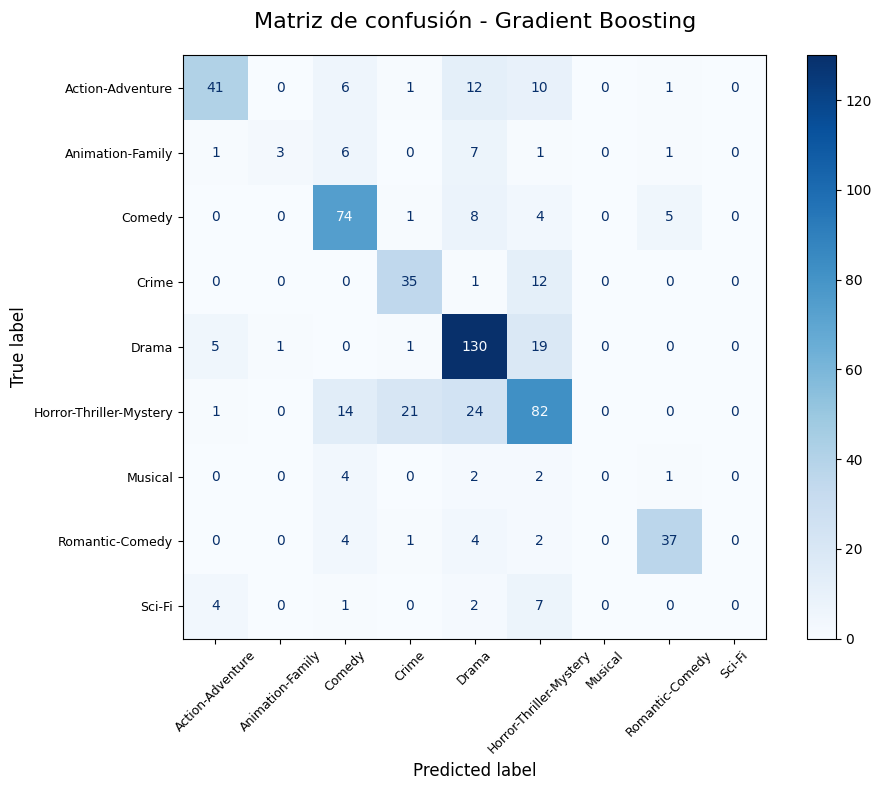

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))  # 👈 tamaño adecuado

disp = ConfusionMatrixDisplay.from_estimator(
    xgb_pipeline_v2,
    X_test,
    y_test,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

# Títulos y labels
ax.set_title("Matriz de confusión - Gradient Boosting", fontsize=16, pad=20)
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)

# Tamaño de texto
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

# Ajuste automático
plt.tight_layout()

plt.show()

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb_pipeline_v2, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

print("Scores (XB 2) en cada fold:", scores)
print("Accuracy (XB 2) promedio:", scores.mean())

Scores (XB 2) en cada fold: [0.6743215  0.63465553 0.67223382 0.66527197 0.63598326]
Accuracy (XB 2) promedio: 0.6564932172150837


Observamos que al hacer el ajuste de hiperparámetros, obtuvimos un rendimiento general igual que con el modelo base. Además, tampoco se logró superar a los resultados obtenidos con Random Forest.

Es por eso que, se realizará un último intento para mejorar el modelo (intentando balancear las clases) únicamente para ***Random Forest***.

### ***Balanceo de clases con SMOTE***


In [ ]:

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Random Forest + SMOTE
pipeline_rf_smote = ImbPipeline([
    ("drop_columns", DropColumns(columns_to_drop=["year", "title","imdb_title_id","director", "longitud_titulo", "duration"])),
    ("music_index_creator", MovieIndexCreator()),
    ("column_transform", column_transform),
    ("smote", SMOTE(random_state=42 , k_neighbors=1)),
    ("model", RandomForestClassifier(random_state=42))
])

pipeline_rf_smote.fit(X_train, y_train)

y_pred_rf_smote = pipeline_rf_smote.predict(X_test)

evaluar_modelo_prediccion("Random Forest + SMOTE", y_test, y_pred_rf_smote)



 MODELO: Random Forest + SMOTE

Reporte de clasificación:
                         precision    recall  f1-score   support

       Action-Adventure      0.692     0.507     0.585        71
       Animation-Family      0.000     0.000     0.000        19
                 Comedy      0.637     0.783     0.702        92
                  Crime      0.603     0.729     0.660        48
                  Drama      0.665     0.865     0.752       156
Horror-Thriller-Mystery      0.580     0.563     0.571       142
                Musical      0.000     0.000     0.000         9
        Romantic-Comedy      0.800     0.583     0.675        48
                 Sci-Fi      0.000     0.000     0.000        14

               accuracy                          0.644       599
              macro avg      0.442     0.448     0.438       599
           weighted avg      0.603     0.644     0.616       599

Matriz de confusión:
[[ 36   0   6   1  17  11   0   0   0]
 [  0   0   8   0   5   6   0   0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



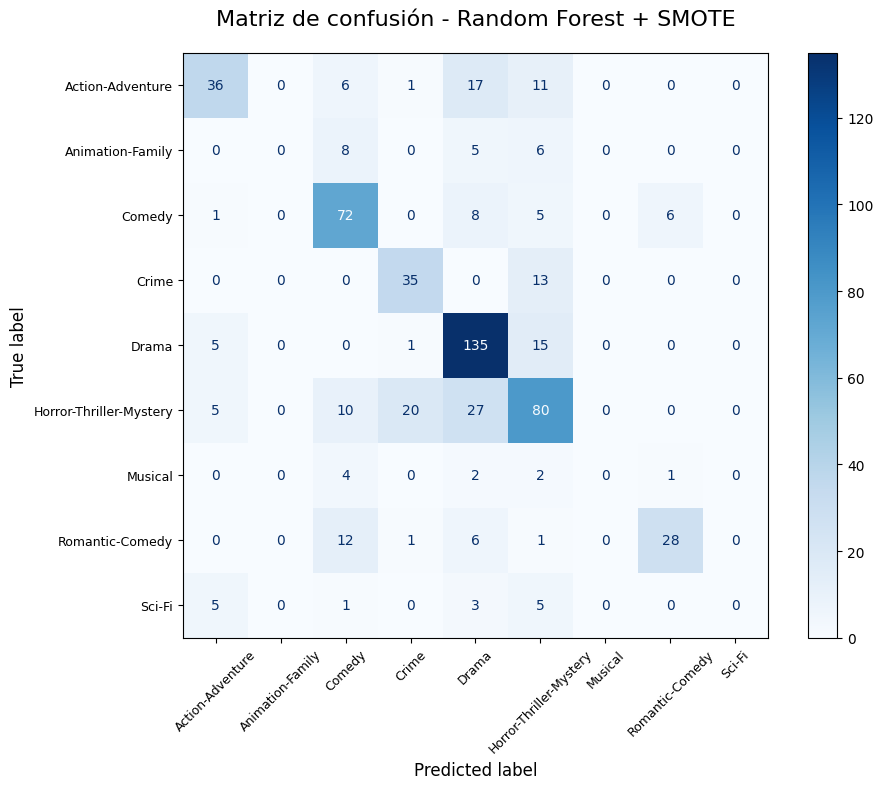

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay.from_estimator(
    pipeline_rf_smote,
    X_test,
    y_test,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

# Título y etiquetas
ax.set_title("Matriz de confusión - Random Forest + SMOTE", fontsize=16, pad=20)
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)

# Tamaño de texto
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

# Ajuste automático
plt.tight_layout()

plt.show()


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline_rf_smote, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

print("Scores (RF + smote) en cada fold:", scores)
print("Accuracy (RF + smote) promedio:", scores.mean())

Scores (RF + smote) en cada fold: [0.66597077 0.6263048  0.65135699 0.65271967 0.64435146]
Accuracy (RF + smote) promedio: 0.64814073951136


Observamos que al balancear las clases se obtiene un rendimiento ligeramente menor que sin el balanceo (accuracy = 20%). Sin embargo, al observar el rendimiento del modelo para cada género, consideramos que se ha obtenido una mejora, ya que a pesar de tener una menor precisión para ciertos géneros, para algunos mejoró.

Entonces, dado que la pérdida del `accuracy` es mínima y el promedio general de `F1` es casi igual, consideramos que el modelo elegido es: ***Random Forest básico***, ya que el objetivo de nuestro sistema de recomendación es lograr una predicción más equitativa entre géneros.
Además, con este modelo observamos una mejora en el recall de las clases minoritarias, lo que significa que el modelo ahora encuentra y clasifica correctamente más canciones de dichas clases minoritarias que antes. Por lo tanto, aunque el modelo sacrifica una fracción de precisión general, se logra una distribución de aciertos más equitativa y justa entre todos los géneros. Y como consideramos que la diversidad es más importante que la máxima precisión sólo para ciertas clases, creemos que este modelo es el que ofrece el mejor equilibrio.





---


## ***Entrenamiento de modelos: Aprendizaje No Supervisado***
A diferencia del Aprendizaje Supervisado, en este tipo de modelos lo que queremos hacer es simplemente *explorar los datos* y *aprender de la naturaleza* de los mismos, sin la idea de llegar a un resultado como en la sección anterior.

En este tipo de aprendizaje, no hay respuestas correctas, solo ***descubrimientos***.

En primer lugar, vamos a colocar la función que vamos a llamar más adelante para seleccionar las features que vamos a utilizar en esta técnica.

In [ ]:
import re
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureSelector(BaseEstimator, TransformerMixin):
    """
    Selecciona columnas numéricas con baja cantidad de nulos,
    excluyendo aquellas que coincidan con patrones o listas explícitas.
    """
    def __init__(self, umbral_nulos=0.05, excluir_columnas=None, excluir_patrones=None):
        self.umbral_nulos = umbral_nulos
        self.excluir_columnas = excluir_columnas or []
        self.excluir_patrones = excluir_patrones or []

    def fit(self, X, y=None):
        columnas_numericas = X.select_dtypes(include=["number"]).columns
        proporcion_nulos = X[columnas_numericas].isnull().mean()

        columnas_utiles = [
            col for col in columnas_numericas
            if proporcion_nulos[col] <= self.umbral_nulos
        ]

        self.columnas_seleccionadas_ = [
            col for col in columnas_utiles
            if col not in self.excluir_columnas
            and not any(pat in col for pat in self.excluir_patrones)
        ]
        return self

    def transform(self, X):
        return X[self.columnas_seleccionadas_]

Vamos a llamar la función de la celda anterior, eliminando las columnas que queremos excluir del DataFrame.

Se guardará el resultado en `df_mood`, y se mostrará la cantidad y el nombre de las columnas que tiene el mismo.

In [ ]:
features_mood = ['sad', 'happy', 'romantic', 'dark', 'humorous',
                 'adventurous', 'fantastical', 'intense', 'mysterious', 'friendly']

df_mood = df[features_mood].copy()

print(f"Columnas seleccionadas: {df_mood.shape[1]}")
df_mood.columns

Columnas seleccionadas: 10


Index(['sad', 'happy', 'romantic', 'dark', 'humorous', 'adventurous',
       'fantastical', 'intense', 'mysterious', 'friendly'],
      dtype='object')

### ***1. Reducción de dimensionalidad con PCA***
En esta técnica, lo que se intenta hacer es simplificar los datos existentes del modelo, utilizando lo que se llaman las "componentes principales" y el análisis de las mismas (PCA - Principal Component Analysis).
Estas componentes principales resumen la mayor parte de la información.

#### *PCA Adaptativo*
A través de esta técnica, vamos a ver cuántas componentes se deben mantener para alcanzar un umbral de varianza acumulada. En este caso, vamos a establecer este umbral en 80%.

Para utilizar PCA, vamos a crear la clase de la celda siguiente, en la cual establecemos algunas funciones útiles.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

class PCAReducerByVariance(BaseEstimator, TransformerMixin):
    def __init__(self, varianza_objetivo=0.95):
        self.varianza_objetivo = varianza_objetivo

    def fit(self, X, y=None):
        self.feature_names_ = list(X.columns)

        X_proc = SimpleImputer(strategy="median").fit_transform(X)

        X_proc = StandardScaler().fit_transform(X_proc)

        pca_temp = PCA().fit(X_proc)

        self.varianza_acumulada_ = pca_temp.explained_variance_ratio_.cumsum()

        self.n_componentes_ = (self.varianza_acumulada_ >= self.varianza_objetivo).argmax() + 1
        # self.n_componentes_ = 2
        print(f"\n Se necesitan {self.n_componentes_} componentes para explicar al menos el {self.varianza_objetivo:.2%} de la varianza.")

        self.pipeline_ = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=self.n_componentes_))
        ])
        self.pipeline_.fit(X)

        return self

    def transform(self, X):
        return self.pipeline_.transform(X)

    def plot_varianza_acumulada(self):
        if not hasattr(self, "varianza_acumulada_"):
            raise RuntimeError("Debés ajustar el modelo con fit() antes de graficar.")

        plt.figure(figsize=(8, 5))
        plt.plot(range(1, len(self.varianza_acumulada_)+1), self.varianza_acumulada_, marker="o")
        plt.axhline(self.varianza_objetivo, color="gray", linestyle="--", label=f"{self.varianza_objetivo:.0%} de varianza")
        plt.title("Varianza acumulada por número de componentes")
        plt.xlabel("Número de componentes principales")
        plt.ylabel("Varianza acumulada")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_heatmap_componentes(self):
        if not hasattr(self, "pipeline_"):
            raise RuntimeError("Debés ajustar el modelo con fit() antes de graficar.")

        pca = self.pipeline_.named_steps["pca"]
        componentes = pca.components_
        df_comp = pd.DataFrame(
            data=componentes,
            columns=self.feature_names_,
            index=[f"PC{i+1}" for i in range(componentes.shape[0])]
        ).T

        plt.figure(figsize=(max(10, 0.5 * self.n_componentes_), 0.3 * len(self.feature_names_)))
        sns.heatmap(df_comp, cmap="coolwarm", center=0, annot=True, fmt=".2f", cbar=True)
        plt.title(f"Contribución de cada característica a las primeras {self.n_componentes_} componentes")
        plt.xlabel("Componentes principales")
        plt.ylabel("Características originales")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

    def get_num_componentes(self):
        return self.n_componentes_

    def get_componentes_dataframe(self):
        pca = self.pipeline_.named_steps["pca"]
        return pd.DataFrame(
            data=pca.components_,
            columns=self.feature_names_,
            index=[f"CP{i+1}" for i in range(pca.n_components_)]
        )


Ya creada la clase en la celda anterior, vamos a llamar a la misma enviando la varianza objetivo (en este caso el 80%), y se va a mostrar por pantalla la cantidad de componentes principales necesarias para explicar al menos la varianza objetivo. En este caso, son 9 las componentes principales necesarias.

Luego, se guarda en la variable `X_reducido` el nuevo conjunto de datos donde cada pelicula se describe a partir de las componentes principales creadas.

In [ ]:
pca = PCAReducerByVariance(varianza_objetivo=0.80)
X_reducido = pca.fit_transform(df_mood)


 Se necesitan 8 componentes para explicar al menos el 80.00% de la varianza.


El siguiente gráfico describe la cantidad de componentes principales necesarias para explicar cada porcentaje de la varianza.

Como dato de interés, sabemos que ya con 4 componentes, se explica más de la mitad de la información.

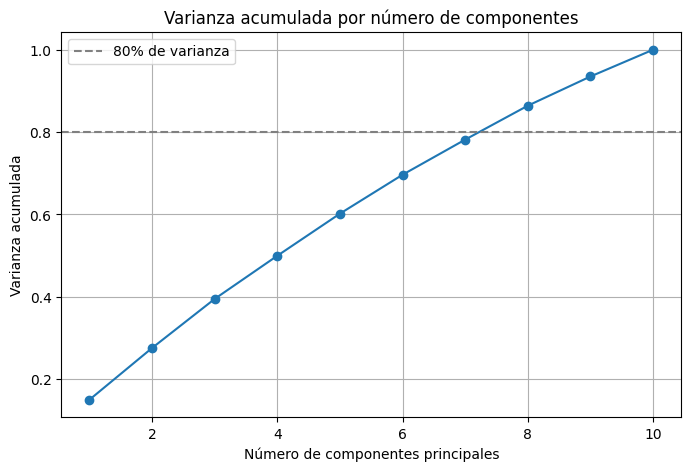

In [ ]:
pca.plot_varianza_acumulada()

En el siguiente gráfico, vamos a ver cuánto aporta cada característica de las canciones a la construcción de las primeras 8 componentes principales.

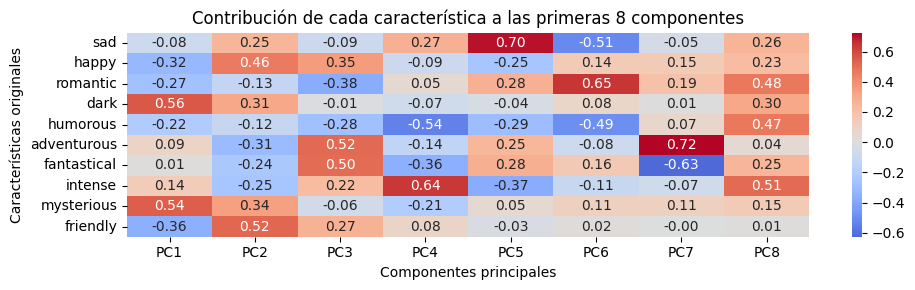

In [ ]:
pca.plot_heatmap_componentes()

Hay variables que dominan cada uno de los componentes (PC1 - PC8):

* **PC1**: está mayormente dominada positivamente por las características `dark` (0.58), `mysterious` (0.55)
y `adventurous`, mientras que presenta valores negativos en `happy` (-0.32) y `humorous` (-0.25).
Esto sugiere que esta componente está asociada a películas con tonos más oscuros, intensos o de suspenso.

* **PC2**: está dominada positivamente por `happy` (0.54) y `friendly` (0.58), y negativamente por
`romantic` (-0.34) y `humorous` (-0.34). Esto podría indicar una dimensión vinculada a contenidos
más accesibles o familiares, en contraste con otros tonos más emocionales o humorísticos.

* **PC3**: esta componente presenta valores positivos en `adventurous` (0.59) y `fantastical` (0.54),
mientras que tiene una fuerte carga negativa en `intense` (-0.43) y `fantastical`. Esto sugiere
una dimensión más orientada a la aventura y la acción frente a contenidos de alta intensidad emocional.

* **PC4**: está fuertemente dominada por `sad` (0.70) e `intense` (0.74) con alta contribución positiva.
Negativamente, aparecen `humorous` (-0.43) y `fantastical`. Esto indica una componente asociada
a contenidos dramáticos y emocionalmente intensos.

* **PC5**: está dominada positivamente por `intense` (0.74) y `adventurous` (0.72), mientras que tiene
contribuciones negativas en `fantastical` (-0.66) y `sad` (-0.36). Esto podría representar contenidos
de acción con alta intensidad pero sin elementos fantásticos ni dramáticos.

* **PC6**: está dominada principalmente por `happy` (0.63) y `mysterious` (0.59) con contribución positiva,
mientras que presenta valores negativos en `sad` (-0.47) y `adventurous` (-0.40). Esto sugiere una
dimensión vinculada a lo misterioso pero con tono positivo.

* **PC7**: esta componente muestra una fuerte influencia positiva de `adventurous` (0.72) y, en menor
medida, de `fantastical`, mientras que tiene valores negativos en `fantastical` (-0.66). Esto podría
representar una dimensión de aventura y exploración.

* **PC8**: está dominada positivamente por `happy` (0.57) y `romantic` (0.57), mientras que presenta
valores negativos en `dark` (-0.30). Esto sugiere una combinación de elementos románticos y positivos,
con menor presencia de tonos oscuros.

#### *PCA Fijo para Visualización*
Esta técnica es ideal para visualizar los datos del dataset. Con esta técnica, podemos detectar si se crean agrupamientos de los datos.

Vamos a comenzar definiendo la clase `PCAPipeline`, que vamos a ir llamando luego.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

class PCAPipeline(BaseEstimator, TransformerMixin):
    """
    Pipeline que aplica imputación + escalado + PCA a n componentes.
    """
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=self.n_components))
        ])

    def fit(self, X, y=None):
        self.pipeline.fit(X)
        return self

    def transform(self, X):
        return self.pipeline.transform(X)

    def get_pca_model(self):
        return self.pipeline.named_steps["pca"]

También definiremos esta función `plot_scatter_pca`, que usaremos para graficar la proyección en 2D por PCA.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_scatter_pca(X_pca, etiquetas=None, titulo="Proyección en 2D por PCA"):
    """
    Grafica un scatterplot con los dos primeros componentes principales.

    Parámetros:
    - X_pca: ndarray o DataFrame con al menos 2 columnas (PC1, PC2).
    - etiquetas: opcional, Series o array para colorear los puntos.
    - titulo: título del gráfico.
    """
    if isinstance(X_pca, pd.DataFrame):
        x = X_pca.iloc[:, 0]
        y = X_pca.iloc[:, 1]
    else:
        x = X_pca[:, 0]
        y = X_pca[:, 1]

    plt.figure(figsize=(8, 6))
    if etiquetas is None:
        plt.scatter(x, y, alpha=0.5, s=10)
    else:
        sns.scatterplot(x=x, y=y, hue=etiquetas, palette="Set2", alpha=0.6, s=20)

    plt.title(titulo)
    plt.xlabel("Componente principal 1")
    plt.ylabel("Componente principal 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_scatter_pca(X_pca, comp1=0, comp2=1, etiquetas=None, titulo="PCA"):

    if isinstance(X_pca, pd.DataFrame):
        x = X_pca.iloc[:, comp1]
        y = X_pca.iloc[:, comp2]
    else:
        x = X_pca[:, comp1]
        y = X_pca[:, comp2]

    plt.figure(figsize=(8,6))

    if etiquetas is None:
        plt.scatter(x, y, alpha=0.5, s=10)
    else:
        sns.scatterplot(x=x, y=y, hue=etiquetas, palette="Set2", alpha=0.6, s=20)

    plt.xlabel(f"PC{comp1+1}")
    plt.ylabel(f"PC{comp2+1}")
    plt.title(titulo)
    plt.grid(True)
    plt.show()

En la siguiente celda, vamos a definir qué features se van a seleccionar para el análisis, y se va a graficar la proyección en dos dimensiones.

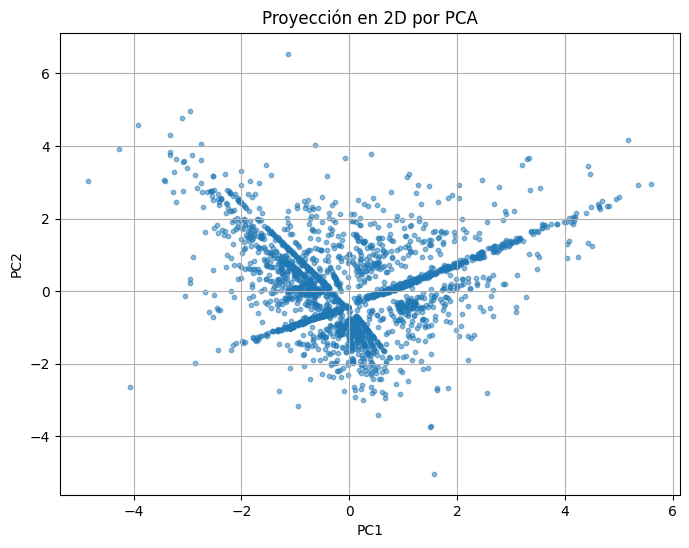

In [ ]:
pca_2d = PCAPipeline(n_components=2)
pca_2d.fit(df_mood)
X_reducido_2d = pca_2d.transform(df_mood)

plot_scatter_pca(X_reducido_2d, titulo="Proyección en 2D por PCA")

En el gráfico anterior podemos ver que no se visualizan o diferencian grupos de datos. En su lugar, los datos representan una sola nube de puntos.

Lo anterior nos sugiere que no hay grandes diferencias o características representativas de cada género, sino que estos suelen mezclarse. Además, sugiere que es necesario utilizar otras técnicas como la clusterización para reconocer grupos de datos similares.

Igualmente, vamos a graficar un heatmap de cómo contribuye cada característica de las peliculas a los componentes PC1 y PC2, para ver si podemos sacar alguna conclusión interesante.

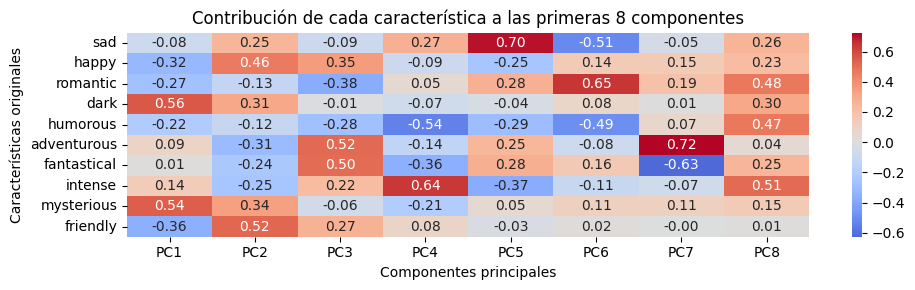

In [ ]:
pca.plot_heatmap_componentes()

* La **componente principal 1 (PC1)** está influida positivamente por las características `dark` (0.58)
y `mysterious` (0.55), pero negativamente por `happy` (-0.32), `friendly` (-0.29) y `humorous` (-0.25).
Como punto de partida, aquí tendríamos películas con tonos más oscuros o de suspenso, con menor
presencia de elementos ligeros o familiares.

* La **componente principal 2 (PC2)** está influida positivamente por las características `friendly` (0.58)
y `happy` (0.54), pero negativamente por `romantic` (-0.34) y `humorous` (-0.34). Como punto de partida,
aquí tendríamos películas más accesibles o familiares, en contraste con otras de tono más emocional
o humorístico.

Para ver si se puede mejorar el análisis, vamos a realizar el mismo gráfico pero esta vez separando por géneros.

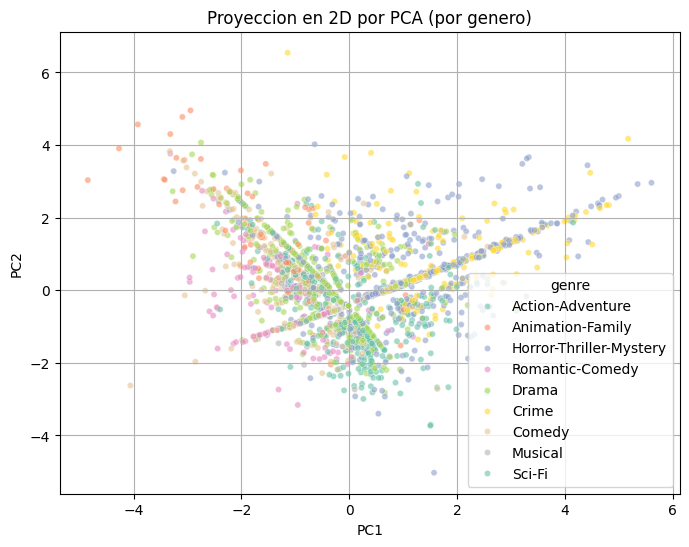

In [ ]:
plot_scatter_pca(X_reducido_2d, etiquetas=df["genre"], titulo="Proyeccion en 2D por PCA (por genero)")

El análisis mediante PCA muestra que no se forman agrupaciones claras de películas según su género. Los datos presentan una alta concentración cerca del origen, lo que indica similitud entre la mayoría de las observaciones. Además, se identifican valores atípicos que podrían estar influyendo en la distribución. La dispersión observada sugiere que las variables utilizadas no logran discriminar adecuadamente entre los distintos géneros, posiblemente debido a la falta de normalización o a la presencia de variables dominantes.



---


#### Exploración en 3D
En esta subsección, vamos a realizar la proyección en tres dimensiones para realizar un análisis más profundo.

In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np

def plot_3d_pca(X_pca, etiquetas=None, titulo="Proyección PCA (3D)"):
    """
    Grafica la proyección de datos en 3D usando Plotly.

    Parámetros:
    - X_pca: ndarray o DataFrame con al menos 3 columnas (PC1, PC2, PC3)
    - etiquetas: opcional, Series o array para colorear los puntos.
    - titulo: título del gráfico
    """
    if isinstance(X_pca, np.ndarray):
        X_pca = pd.DataFrame(X_pca, columns=["pca_1", "pca_2", "pca_3"])

    df_plot = X_pca.copy()
    if etiquetas is not None:
        df_plot["etiqueta"] = etiquetas
    else:
        df_plot["etiqueta"] = "Punto"

    fig = px.scatter_3d(
        df_plot,
        x="pca_1", y="pca_2", z="pca_3",
        color="etiqueta",
        opacity=0.6,
        title=titulo
    )
    fig.update_traces(marker=dict(size=3))
    fig.show()

En la siguiente celda de código, se llama a la función anterior con la cual se graficará en tres dimensiones.

In [ ]:
pca_3d = PCAPipeline(n_components=3)
pca_3d.fit(df_mood)
X_reducido_3d = pca_3d.transform(df_mood)

plot_3d_pca(X_reducido_3d, titulo="Proyección PCA (3D)")

Ya con el gráfico anterior se puede notar una diferencia al visualizar los datos, ya que se ven más completos. Igualmente, vamos a graficar en diferentes colores para ver si se puede mejorar el análisis.

In [ ]:
plot_3d_pca(X_reducido_3d, etiquetas=df["genre"], titulo="Proyección PCA (3D) por género")

El gráfico en 3D anterior refuerza la teoría que suponíamos más temprano: no existen grupos muy formados ni distinguidos en los datos.

Además del motivo que colocamos anteriormente (que las características entre los géneros suelen mezclarse), otro motivo por el que puede suceder esto es que se evidencia la varianza que no es captada por la visualización.

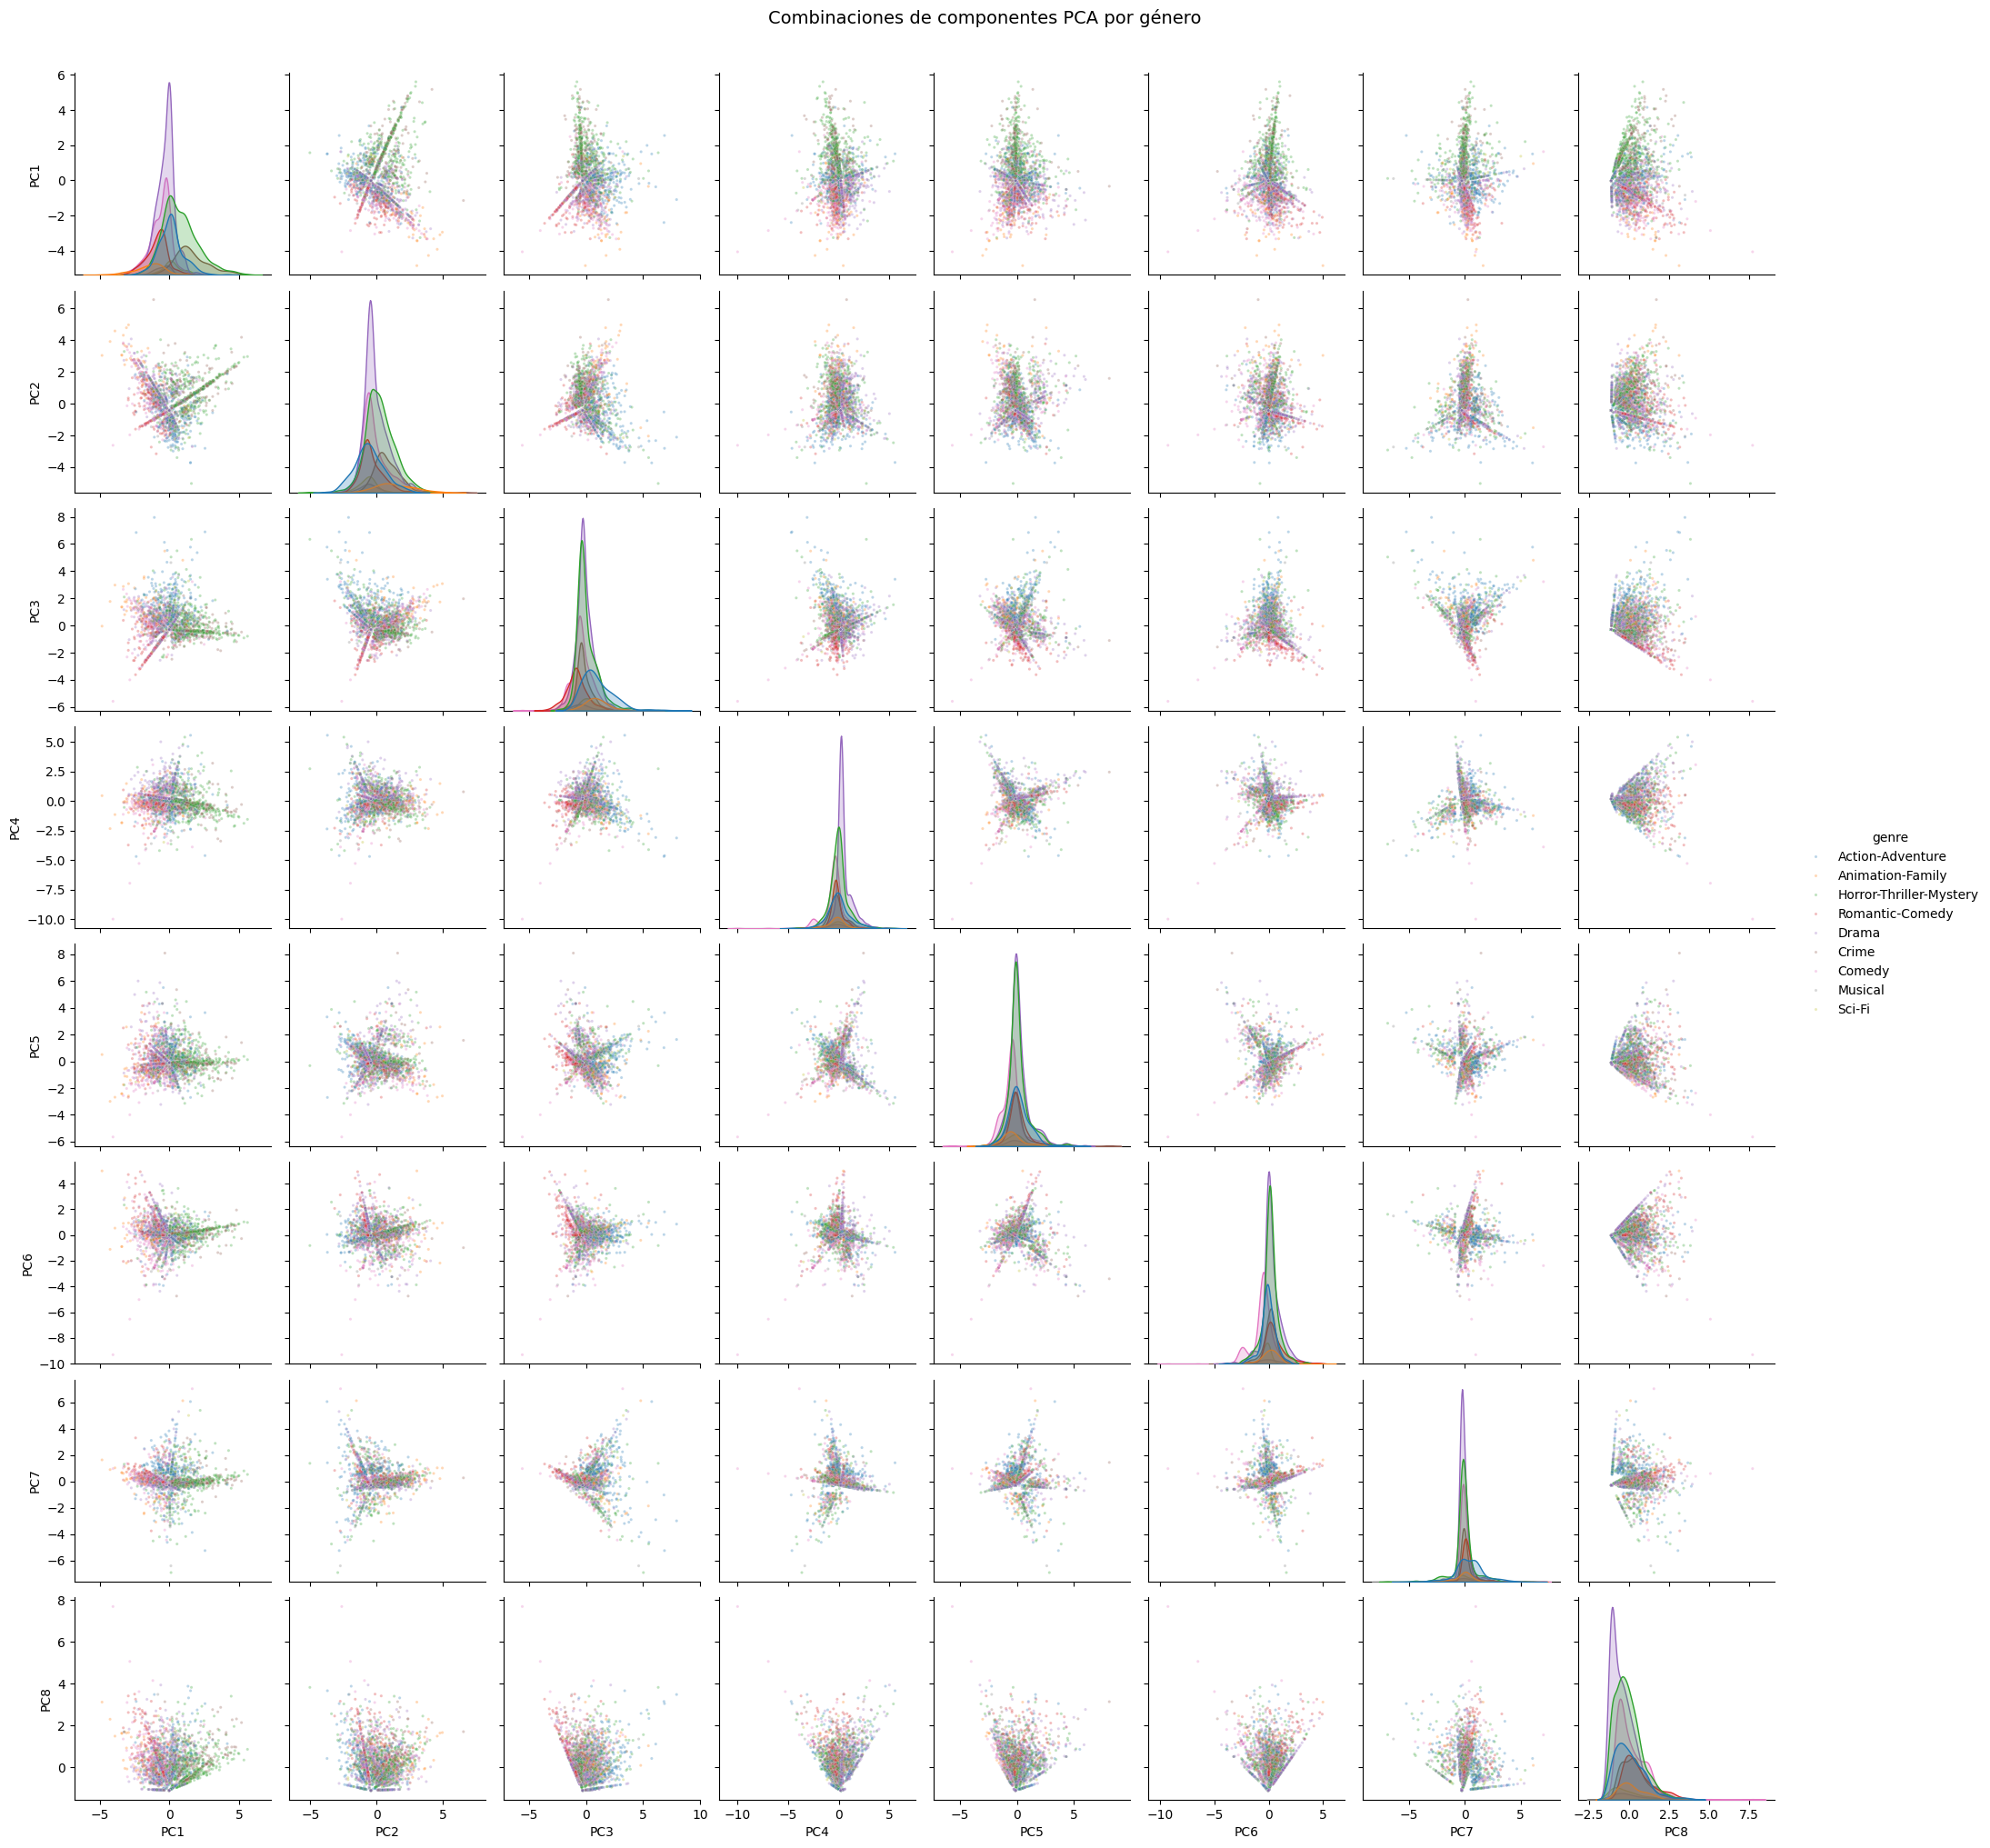

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear dataframe con las 8 componentes
df_pca_8 = pd.DataFrame(
    X_reducido,  # tu variable con las 8 componentes del PCA adaptativo
    columns=[f"PC{i+1}" for i in range(8)]
)
df_pca_8["genre"] = df["genre"].values

# Pairplot con todas las combinaciones
sns.pairplot(
    df_pca_8,
    hue="genre",
    vars=["PC1","PC2","PC3","PC4","PC5","PC6","PC7","PC8"],
    plot_kws={"alpha": 0.3, "s": 5},
    diag_kind="kde"
)
plt.suptitle("Combinaciones de componentes PCA por género", y=1.02, fontsize=14)
plt.show()

El gráfico de combinaciones de componentes PCA confirma lo observado anteriormente:
en ninguna combinación de componentes principales se logra una separación clara entre
géneros. Los puntos de todos los géneros se superponen en todas las proyecciones, lo
que indica que las features de mood por sí solas no son suficientes para distinguir
entre las 24 clases. Esto sugiere que el problema requiere features adicionales o
técnicas de reducción de dimensionalidad orientadas a la separación de clases,
como LDA.

### ***2. Clustering***
El objetivo de esta técnica es agrupar o encontrar grupos ideales para categorizar nuestros datos, encontrando la mayor división que se ajuste a las propiedas o características de los mismos.

En esta primera celda de código, vamos a definir la clase `KMeansAutoCluster`, que contiene algunas funciones útiles.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import numpy as np
import matplotlib.pyplot as plt

class KMeansAutoCluster(BaseEstimator, TransformerMixin):
    """
    Aplica KMeans eligiendo automáticamente la mejor cantidad de clusters
    según el Silhouette Score. Permite graficar la curva resultante y acceder
    al valor óptimo de k y a las etiquetas generadas.
    """
    def __init__(self, k_range=range(2, 11), random_state=42):
        self.k_range = list(k_range)
        self.random_state = random_state

    def fit(self, X, y=None):
        self.inertias_ = []
        self.silhouettes_ = []
        self.k_models_ = {}

        for k in self.k_range:
            model = KMeans(n_clusters=k, random_state=self.random_state, n_init="auto")
            labels = model.fit_predict(X)
            self.k_models_[k] = model
            self.inertias_.append(model.inertia_)
            # el silohouette mide que tan clusters son los clusters
            self.silhouettes_.append(silhouette_score(X, labels))

        self.k_optimo_ = self.k_range[np.argmax(self.silhouettes_)]
        print(f"el número de clusters óptimo es {self.k_optimo_} con un índice de silueta de {max(self.silhouettes_)} \n")
        self.best_model_ = self.k_models_[self.k_optimo_]
        self.labels_ = self.best_model_.predict(X)
        return self.best_model_.fit(X)

    def predict(self, X):
        return self.best_model_.predict(X)

    def get_labels(self):
        return self.labels_

    def get_optimal_k(self):
        return self.k_optimo_

    def plot_silhouette_curve(self):
        plt.figure(figsize=(6, 4))
        plt.plot(self.k_range, self.silhouettes_, marker="o", color="green")
        plt.axvline(self.k_optimo_, color="gray", linestyle="--", label=f"k óptimo = {self.k_optimo_}")
        plt.title("Silhouette Score vs cantidad de clusters")
        plt.xlabel("Número de clusters")
        plt.ylabel("Silhouette Score")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

Con la siguiente celda de código, vamos a hacer uso de la clase definida en la celda anterior, para imprimir la cantidad de clusters óptimo junto con el índice de silueta o "silhouette score" en dos, tres y cinco dimensiones.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Preprocesar las 10 features de mood
prepro = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
X_scaled = prepro.fit_transform(df_mood)

# Usar muestra para encontrar k optimo (mas rapido)
df_muestra = df_mood.sample(n=2000, random_state=42)
X_muestra = prepro.transform(df_muestra)

pca2d = PCAPipeline(n_components=2)
pca3d = PCAPipeline(n_components=3)
pca5d = PCAPipeline(n_components=5)

X_2d = pca2d.fit(df_muestra).transform(df_muestra)
X_3d = pca3d.fit(df_muestra).transform(df_muestra)
X_5d = pca5d.fit(df_muestra).transform(df_muestra)

# Rango reducido de k (ya sabemos que el optimo es 3)
cluster_2d = KMeansAutoCluster(k_range=range(2, 6))
cluster_3d = KMeansAutoCluster(k_range=range(2, 6))
cluster_5d = KMeansAutoCluster(k_range=range(2, 6))

cluster_2d.fit(X_2d)
cluster_3d.fit(X_3d)
cluster_5d.fit(X_5d)

el número de clusters óptimo es 3 con un índice de silueta de 0.4697729883335051 

el número de clusters óptimo es 4 con un índice de silueta de 0.4063987886463742 

el número de clusters óptimo es 5 con un índice de silueta de 0.3193810891846217 



KMeans(n_clusters=5, random_state=42)

Para mayor claridad, graficaremos el silhouette score en cada dimensión, cuando la cantidad de clusters va subiendo.

In [ ]:
import matplotlib.pyplot as plt

def plot_multiple_silhouettes(modelos, nombres=None, figsize=(5, 4)):
    """
    Dibuja los gráficos de Silhouette Score de múltiples modelos KMeansAutoCluster en una sola fila.

    Parámetros:
    - modelos: lista de objetos KMeansAutoCluster ya entrenados
    - nombres: lista de títulos opcionales para cada subplot
    - figsize: tamaño base de cada gráfico individual (ancho, alto)
    """
    n = len(modelos)
    fig, axes = plt.subplots(1, n, figsize=(figsize[0]*n, figsize[1]), sharey=True)

    if n == 1:
        axes = [axes]

    for i, (modelo, ax) in enumerate(zip(modelos, axes)):
        k_range = modelo.k_range
        sils = modelo.silhouettes_
        k_opt = modelo.get_optimal_k()

        ax.plot(k_range, sils, marker="o", color="green")
        ax.axvline(k_opt, color="gray", linestyle="--", label=f"k óptimo = {k_opt}")
        ax.set_xlabel("Clusters (k)")
        if i == 0:
            ax.set_ylabel("Silhouette Score")
        if nombres:
            ax.set_title(nombres[i])
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()


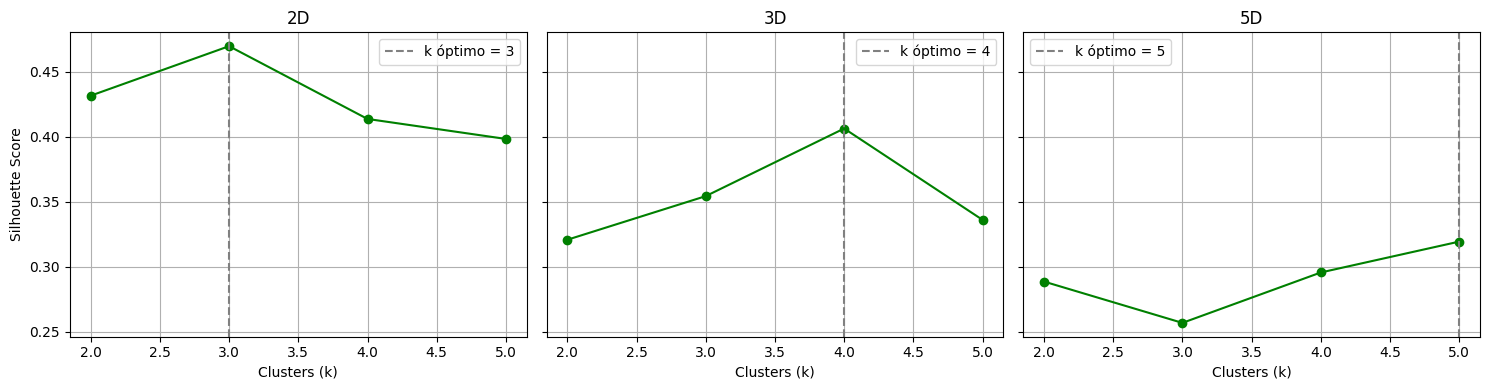

In [ ]:
plot_multiple_silhouettes(¿
    [cluster_2d, cluster_3d, cluster_5d],
    nombres=["2D", "3D", "5D"]
)

En estos gráficos vemos que el k óptimo varía según la dimensión utilizada: en 2D el mejor k es 3, en 3D es 4, y en 5D es 8. A mayor dimensión, los clusters se vuelven más específicos pero con menor silhouette score, lo que indica que la separación es más débil. Para el recomendador vamos a usar k=3 sobre las 10 features de mood directamente, por ser el más interpretable y con el mayor silhouette score.

### ***3. PCA + Clustering***
En esta sección, vamos a reutilizar todo lo que realizamos anteriormente, en un solo pipeline completo.

Comenzamos definiendo la clase que se va a utilizar en Pipeline, más adelante.

En esta celda aplicamos KMeans con k=3 (el valor óptimo encontrado anteriormente)
sobre las 10 features de mood escaladas. Se agregan las etiquetas de cluster al
DataFrame original para su posterior análisis.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Preprocesar las 10 features de mood
prepro = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
X_scaled = prepro.fit_transform(df_mood)

# Entrenar con k=3 (el óptimo encontrado)
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init="auto")
clusters = kmeans_final.fit_predict(X_scaled)

# Agregar cluster al df
df["cluster"] = clusters
print(df["cluster"].value_counts())

cluster
0    2286
1     618
2      88
Name: count, dtype: int64


Para visualizar los clusters en 2D, proyectamos las 10 features de mood a 2
componentes principales. Cada punto representa una película, coloreada según
su cluster asignado.

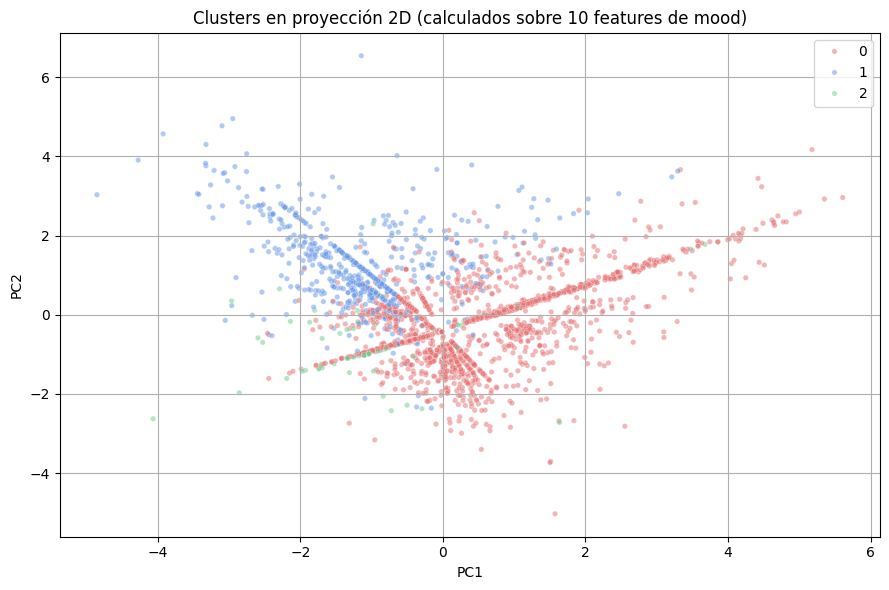

In [ ]:
# Proyectar a 2D solo para visualizar
from sklearn.decomposition import PCA

pca_viz = PCA(n_components=2, random_state=42)
X_2d_viz = pca_viz.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_2d_viz[:, 0], y=X_2d_viz[:, 1],
                hue=clusters, palette=["#E66E6E", "#6496E8", "#6ECC8E"],
                alpha=0.5, s=15, legend="full")
plt.title("Clusters en proyección 2D (calculados sobre 10 features de mood)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

El gráfico radar muestra el perfil emocional promedio de cada cluster.


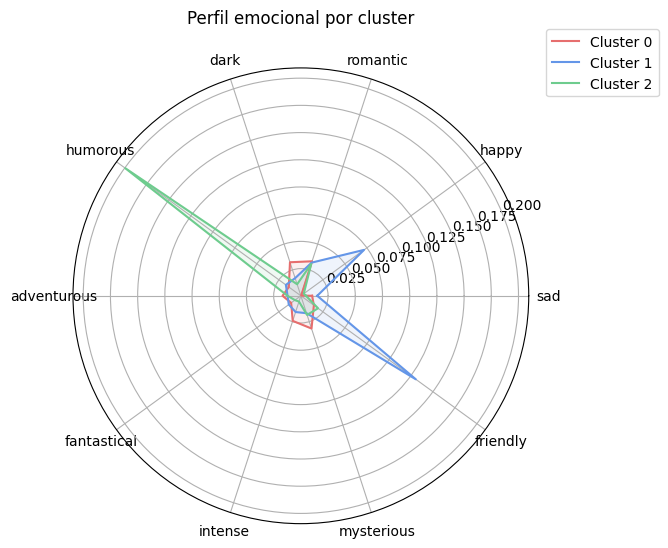

            sad   happy  romantic    dark  humorous  adventurous  fantastical  \
cluster                                                                         
0        0.0103  0.0004    0.0333  0.0324    0.0137       0.0169       0.0111   
1        0.0151  0.0718    0.0320  0.0171    0.0170       0.0123       0.0137   
2        0.0047  0.0033    0.0307  0.0111    0.1995       0.0123       0.0068   

         intense  mysterious  friendly  
cluster                                 
0         0.0242      0.0316    0.0148  
1         0.0157      0.0168    0.1306  
2         0.0056      0.0185    0.0195  


In [ ]:
medias = df.groupby("cluster")[features_mood].mean()

angles = np.linspace(0, 2 * np.pi, len(features_mood), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colores = ["#E66E6E", "#6496E8", "#6ECC8E"]

for i, row in medias.iterrows():
    valores = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, valores, label=f"Cluster {i}", color=colores[i])
    ax.fill(angles, valores, alpha=0.1, color=colores[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features_mood, fontsize=10)
ax.set_title("Perfil emocional por cluster", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

print(medias.round(4))

Analizando los valores numéricos:

-Cluster 0 ("Intenso/Oscuro"): presenta valores relativamente más altos en dimensiones como dark, mysterious e intense, junto con una leve presencia de romantic. Representa contenido más emocional, dramático o con tonos más profundos.
-Cluster 1 ("Positivo/Amigable"): se destaca claramente en friendly (0.1306) y happy (0.0718), siendo el cluster con mayor carga positiva. Representa contenido liviano, optimista y accesible.
-Cluster 2 ("Humor/Comedia"): muestra un valor muy alto en humorous (0.1995), significativamente superior al resto de las dimensiones. Representa contenido orientado al humor y la comedia.

In [ ]:
print(df.groupby("cluster")["genre"].value_counts().unstack(fill_value=0))

genre    Action-Adventure  Animation-Family  Comedy  Crime  Drama  \
cluster                                                             
0                     276                12     301    209    613   
1                      78                80     105     26    164   
2                       3                 1      51      4      4   

genre    Horror-Thriller-Mystery  Musical  Romantic-Comedy  Sci-Fi  
cluster                                                             
0                            595       36              182      62  
1                            107        3               49       6  
2                              7        4               11       3  


Esta tabla muestra cuántas películas de cada género cayeron en cada cluster.
Los resultados más destacados son:

- **Romantic-Comedy** se distribuye casi igualmente entre Cluster 0 y Cluster 1
  (2570 vs 2595), lo que tiene sentido dado su mix de romance y humor.
- **Scare** predomina en Cluster 1 (13.324), siendo el género más presente en
  el cluster neutro/mixto.
- **Drama** aparece masivamente en Cluster 1 (8.183) y Cluster 2 (3.058).
- **Thrill** también domina en Cluster 1 (5.256).

Esto confirma que ningún cluster captura un género específico de forma exclusiva,
reforzando la conclusión de que el mood solo no es suficiente para separar géneros.

Probando como recomienda, construimos un sistema de recomendación basado en similitud
de mood. Usando KNN con k=6 y distancia euclidiana sobre las features escaladas,
dado el título de una película, el sistema encuentra las 5 más similares en
términos de perfil emocional.

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Resetear el indice del df para que coincida con X_scaled
df = df.reset_index(drop=True)

knn = NearestNeighbors(n_neighbors=6, metric="euclidean")
knn.fit(X_scaled)

def recomendar_peliculas(titulo, n=5):
    mask = df["title"] == titulo
    if mask.sum() == 0:
        print(f"No se encontro '{titulo}'")
        return
    pos = mask.idxmax()  # posicion directa porque el indice ya esta reseteado
    distancias, indices = knn.kneighbors([X_scaled[pos]])
    return df.iloc[indices[0][1:]][["title", "genre", "cluster"]]

recomendar_peliculas("Stuart Little 2")

,title,genre,cluster
2196,The Big Chance,Action-Adventure,0
1113,Small Soldiers,Action-Adventure,0
1722,La traccia infernale,Action-Adventure,0
2707,La tumba de la isla maldita,Horror-Thriller-Mystery,0
318,West of Shanghai,Action-Adventure,0


In [ ]:
print(df[df["title"] == "Cinderella"][features_mood])
print(df[df["title"] == "Cinderella"]["genre"])

Empty DataFrame
Columns: [sad, happy, romantic, dark, humorous, adventurous, fantastical, intense, mysterious, friendly]
Index: []
Series([], Name: genre, dtype: object)


### ***4. Detección de Anomalías***
Con esta técnica, queremos detectar cuáles son los datos anómalos, es decir, aquellas canciones que no encajan en los Clusters 0 y 1 definidos anteriormente.

Para encontrar estas anomalías, utilizaremos el algoritmo "Isolation Forest".

Lo que hace este algoritmo es realizar "preguntas" a cada pelicula, e identificar aquellas cuyas características sean contradictorias.

Lo que hace el código es definir las características o features a utilizar  y entrenar el modelo. Así, devuelve:
* **1 si se trata de un punto "normal"**
* **-1 si se trata de un punto "anómalo"**

Este resultado lo va a añadir al DataFrame `df_anomalo`, e imprimirá por pantalla la cantidad de anomalías encontradas.

In [ ]:
from sklearn.ensemble import IsolationForest

X = df[features_mood]

iso_forest = IsolationForest(contamination=0.02, random_state=42)
predictions = iso_forest.fit_predict(X)

df['anomaly'] = predictions

print("Numero de anomalias encontradas:", df[df['anomaly'] == -1].shape[0])

Numero de anomalias encontradas: 60


Como se puede ver, el resultado arrojó que se encontraron **39 anomalías**. Esto representa un 0.02% de la cantidad total de peliculas.

Para visualizar las anomalías en un gráfico, vamos a reutilizar lo que hicimos anteriormente de la proyección en 2D, y vamos a resaltar en color rojo aquellos datos que son anómalos. En color gris, se dejan aquellos datos normales.

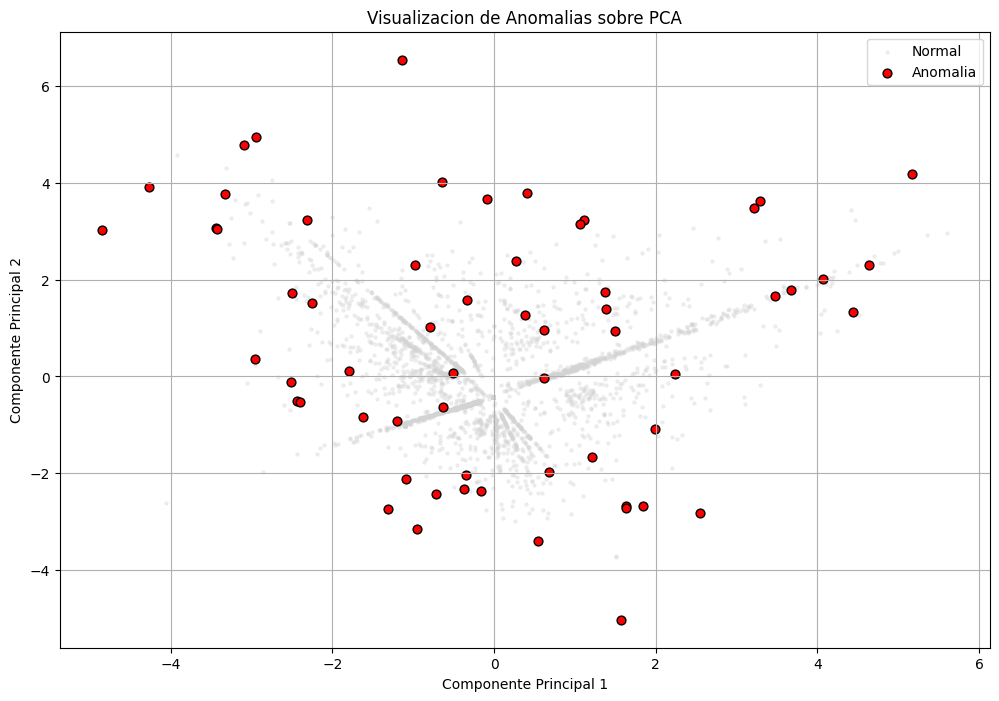

In [ ]:
pca_anom = PCA(n_components=2, random_state=42)
X_pca_2d_anom = pca_anom.fit_transform(X_scaled)

anomaly = df['anomaly'].values

plt.figure(figsize=(12, 8))
plt.scatter(X_pca_2d_anom[anomaly == 1, 0], X_pca_2d_anom[anomaly == 1, 1],
            c='lightgray', label='Normal', s=5, alpha=0.3)
plt.scatter(X_pca_2d_anom[anomaly == -1, 0], X_pca_2d_anom[anomaly == -1, 1],
            c='red', edgecolor='k', s=40, label='Anomalia')

plt.title('Visualizacion de Anomalias sobre PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True)
plt.show()

En el gráfico anterior, se puede notar visualmente que los datos anómalos no representan siquiera un 1% de la cantidad total.

Para analizar algunos ejemplos de peliculas anómalas, imprimiremos una tabla con las mismas, con todas sus características.

In [ ]:
anomalous_movie = df[df['anomaly'] == -1]

print(f"Estas son las {anomalous_movie.shape[0]} peliculas anomalas del dataset:")
display(anomalous_movie[features_mood + ['genre']])

Estas son las 60 peliculas anomalas del dataset:


,sad,happy,romantic,dark,humorous,adventurous,fantastical,intense,mysterious,friendly,genre
19,0.000000,0.061430,0.000000,0.228218,0.000000,0.186654,0.203971,0.120042,0.000000,0.061430,Action-Adventure
39,0.000000,0.148284,0.185855,0.000000,0.000000,0.000000,0.258284,0.000000,0.283886,0.000000,Horror-Thriller-Mystery
48,0.191473,0.091783,0.078718,0.000000,0.058453,0.000000,0.000000,0.000000,0.000000,0.313752,Romantic-Comedy
95,0.000000,0.114324,0.098601,0.000000,0.041931,0.110431,0.000000,0.000000,0.310634,0.000000,Horror-Thriller-Mystery
97,0.152785,0.146476,0.000000,0.135261,0.000000,0.000000,0.000000,0.000000,0.135261,0.410524,Crime
151,0.093760,0.000000,0.000000,0.433397,0.000000,0.000000,0.000000,0.000000,0.220699,0.089445,Crime
194,0.000000,0.000000,0.000000,0.120799,0.000000,0.076247,0.330833,0.129373,0.000000,0.000000,Action-Adventure
211,0.000000,0.000000,0.000000,0.063989,0.044131,0.072226,0.000000,0.254451,0.063989,0.196986,Action-Adventure
217,0.000000,0.000000,0.000000,0.263143,0.181480,0.000000,0.000000,0.000000,0.263143,0.000000,Crime
326,0.000000,0.123487,0.000000,0.000000,0.039322,0.166809,0.408070,0.110354,0.000000,0.123487,Action-Adventure




---


Como conclusión final de la sección de Aprendizaje No Supervisado, podemos decir que hemos conseguido hallazgos interesantes: se logró una segmentación de las películas según su nivel de dinamismo, y no necesariamente por género.

A partir de esta conclusión, pensamos que sería posible aplicar este enfoque en sistemas de recomendación de películas según el tipo de experiencia que busca el usuario. Por ejemplo, si se desea ver una película con mayor intensidad o acción, se podrían recomendar películas del cluster con mayor dinamismo, mientras que si se busca una opción más ligera o relajada, se podrían sugerir películas del cluster con menor dinamismo.

In [ ]:
df.columns

Index(['imdb_title_id', 'title', 'original_title', 'year', 'date_published',
       'genre', 'duration', 'country', 'language', 'director', 'writer',
       'production_company', 'actors', 'description', 'avg_vote', 'votes',
       'reviews_from_users', 'reviews_from_critics', 'decada',
       'longitud_titulo', 'romantic', 'intense', 'sad', 'happy', 'mysterious',
       'dark', 'adventurous', 'fantastical', 'humorous', 'friendly', 'cluster',
       'anomaly'],
      dtype='object')

In [ ]:
# ✅ Agregar los 5 componentes PCA al dataframe
pca_5_export = PCAPipeline(n_components=5)
pca_5_export.fit(df_mood)
X_pca_5 = pca_5_export.transform(df_mood)

df['pca_1'] = X_pca_5[:, 0]
df['pca_2'] = X_pca_5[:, 1]
df['pca_3'] = X_pca_5[:, 2]
df['pca_4'] = X_pca_5[:, 3]
df['pca_5'] = X_pca_5[:, 4]

print("Columnas PCA agregadas:", ['pca_1','pca_2','pca_3','pca_4','pca_5'])
print(df[['pca_1','pca_2','pca_3','pca_4','pca_5']].head())

Columnas PCA agregadas: ['pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5']
      pca_1     pca_2     pca_3     pca_4     pca_5
0  0.285916 -2.078873  1.141837  1.046481 -1.145159
1 -0.846660  0.761325  0.501851  0.110779 -0.515654
2 -1.433423  1.605740  0.955684  0.215642 -0.599449
3 -0.237564 -1.515334  1.362625 -1.938985  0.639294
4 -0.638869 -0.126878 -0.469697 -0.102028 -0.180393


In [ ]:
columnas_deseadas = [
   'title', 'director', 'imdb_title_id', 'year', 'date_published','duration', 'description', 'director', 'actors', 'writer',
    'genre','sad', 'happy', 'romantic', 'dark', 'humorous', 'adventurous',
    'fantastical', 'intense', 'mysterious', 'friendly', 'decada', 'longitud_titulo','pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5','cluster', 'anomaly'
]

df.to_csv(
    'movies_3000.csv',
    index=False,
    columns=columnas_deseadas
)

from google.colab import files
files.download('movies_3000.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>